# SVM Taxi Demand Prediction — Pooled Model

**One pooled SVM model per resolution, instead of one model per spatial unit.**

- Predicts taxi pickup demand (trip counts) per spatial unit per 4h time window.
- One model trained on all spatial units at once, spatial identity as a feature (fixed-effect
  dummies) — instead of fitting a separate model per unit.
- **Why pooled**: scales to hundreds of census tracts without refitting hundreds of models,
  and keeps the same panel-building/evaluation code reusable across resolutions.
- **Course constraint**: no lagged/autoregressive demand features — only exogenous time,
  weather, and spatial-identity inputs.

**Notebook structure**:
1. Data loading (1) & panel construction (2) & features (3)
2. Profile baseline (4)
3. Pooled `LinearSVR` — no kernel, feature importance, demand weighting (5)
4. Kernel comparison & hyperparameter tuning (6–7)
5. Results — model comparison, per-area performance (8)
6. Demand tiering & per-area models above a threshold (9)
7. Shortfalls & honest limitations (10)
8. Outlook: census tract level & other resolutions (11)

## Validation Strategy

- **Chronological holdout**: train 2024-01-01 – 2025-12-31, test 2026-01-01 – 2026-05-31.
- **`KFold` (3 folds, shuffled)** for the pooled kernel/hyperparameter search (section 7) --
  no lagged/historical-demand features are used (course constraint), so there's no
  autoregressive leakage risk a chronological split would guard against, and shuffled folds
  give every fold an even mix of seasons instead of the growing-window bias `TimeSeriesSplit`
  would introduce here. The per-area tuning (section 9.2.2) still uses `TimeSeriesSplit` --
  each area's subset is naturally in chronological order there, so it isn't wrong, just not
  required either.
- **Complete zero-filled grid** (every unit x every window) — models see genuine zero-demand
  windows, not just observed trips.
- **Profile baseline**: train-set mean demand per (hour, weekday, month) per unit — the
  reference model everything else is judged against.
- **Two headline metrics**, reported together for every model:
  - **Skill score**: `1 - MAE_model / MAE_baseline`, per unit -- a ratio, so each unit's own
    demand scale cancels out, comparable across units *and* across resolutions (4h/1h/tract).
    Aggregated demand-weighted (matches the fleet-allocation use case) and unweighted median
    (guard rail against a model that only wins on a few big units).
  - **Weighted RMSE**: pooled RMSE with each row weighted by its unit's train-period mean
    demand -- an absolute, trips/window number (not baseline-relative), and the one
    comparable against the NN notebooks (`03.05`/`03.06`), which report RMSE natively.
- **Plain pooled R2/MAE/RMSE** (every row weighted equally) are a sanity check only, not a
  headline metric -- demand varies ~1000x across units, so these are dominated by the
  busiest ones and hide poor performance elsewhere. Don't confuse with weighted RMSE above.

In [1]:
import time
import warnings
import pathlib

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import contextily as ctx
import holidays

from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.svm import SVR, LinearSVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TAXI_DATA_PATH       = "../../data/chicago_taxi_2024_2026_clean.parquet"
WEATHER_DATA_PATH    = "../../data/chicago_weather_2024_2026_hourly.csv"
COMMUNITY_AREAS_PATH = "../../data/community_areas_chicago.geojson"

# Data range covered by the cleaned parquet (June 2026+ excluded: portal reporting lag)
DATA_START    = pd.Timestamp("2024-01-01")
DATA_END_EXCL = pd.Timestamp("2026-06-01")

# Chronological split: train 2024-2025 (two full years), test Jan-May 2026
TRAIN_END = pd.Timestamp("2026-01-01")

# Evaluation week for baseline comparison
EVAL_WEEK_START = pd.Timestamp("2026-03-02")
EVAL_WEEK_END   = EVAL_WEEK_START + pd.Timedelta(days=7)

FREQ = "4h"  # this draft: community-area resolution at 4h windows only
WEATHER_COLS = ["temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover"]

ALL_AREAS = np.arange(1, 78)  # official community areas 1..77 -- ALL of them, no threshold

# expm1(709) overflows float64; clip the log-scale prediction first so an unstable kernel
# (see the kernel comparison below) gets a very bad but finite score instead of crashing.
LOG_PRED_CAP = 20

# Chart colors (validated palette: sequential blue, diverging blue<->red)
SEQUENTIAL_BLUE = "#256abf"
DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging_blue_red", ["#e34948", "#f0efec", "#2a78d6"])
# Categorical palette -- only needed where >2 series share one axes (the multi-model overlay
# in section 8.2); same palette as 03.05's NN notebook for visual consistency across notebooks.
CATEGORICAL_COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

# Single seed used everywhere randomness enters (subsampling, model random_state, CV) so a
# full rerun is reproducible end to end.
SEED = 42
np.random.seed(SEED)

# LinearSVR (liblinear) at some C values doesn't reach its optimum within max_iter on this
# data -- the fits are still valid (just not at the exact optimum), and raising max_iter
# further would not remove the warning either (liblinear's tolerance is effectively
# unreachable for these C/data combinations). Silenced rather than chasing an unreachable
# tolerance across hundreds of grid-search fits.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

print(f"train: {DATA_START.date()} to {TRAIN_END.date()}  "
      f"test: {TRAIN_END.date()} to {DATA_END_EXCL.date()}")

train: 2024-01-01 to 2026-01-01  test: 2026-01-01 to 2026-06-01


## 1. Data Loading

- Combined 2024–2026 taxi parquet (see `00_data_loading`) + hourly weather.
- Only pickup community area and trip timestamp needed for demand aggregation.

In [2]:
taxi = pd.read_parquet(TAXI_DATA_PATH, columns=["trip_start_timestamp", "pickup_community_area"])
n_raw = len(taxi)
taxi = taxi[taxi["pickup_community_area"].notna()].copy()
taxi["pickup_community_area"] = taxi["pickup_community_area"].astype(int)
print(f"Trips with pickup CA: {len(taxi):,} of {n_raw:,} ({len(taxi)/n_raw*100:.1f}%)")

weather = pd.read_csv(WEATHER_DATA_PATH)
weather["datetime"] = pd.to_datetime(weather["datetime"])
weather = weather[["datetime"] + WEATHER_COLS]
print(f"Weather rows: {len(weather):,}")


Trips with pickup CA: 14,201,846 of 14,465,650 (98.2%)
Weather rows: 21,168


## 2. Building the Pooled Demand Panel

- Complete zero-filled area x window grid, all 77 areas (no demand threshold).
- Time features include a **second harmonic** for hour and day-of-week (captures the
  bimodal morning + evening rush pattern a single harmonic can't).
- Spatial identity: **community-area fixed effects** (one-hot dummies).

In [3]:
# US federal holidays (incl. observed dates), computed for every year the data covers --
# avoids maintaining a hand-picked date list that silently goes stale outside 2024-2026.
US_HOLIDAYS = pd.DatetimeIndex(sorted(
    holidays.US(years=range(DATA_START.year, DATA_END_EXCL.year + 1))
))

window = taxi["trip_start_timestamp"].dt.floor(FREQ).rename("timestamp")
counts = taxi.groupby(["pickup_community_area", window]).size().rename("count")

all_windows = pd.date_range(DATA_START, DATA_END_EXCL, freq=FREQ, inclusive="left")
grid = pd.MultiIndex.from_product([ALL_AREAS, all_windows], names=["community_area", "timestamp"])
panel = counts.reindex(grid, fill_value=0).reset_index()

w = weather.copy()
w["timestamp"] = w["datetime"].dt.floor(FREQ)
w_agg = w.groupby("timestamp")[WEATHER_COLS].mean().reset_index()
panel = panel.merge(w_agg, on="timestamp", how="left")

panel["hour"]        = panel["timestamp"].dt.hour
panel["day_of_week"] = panel["timestamp"].dt.dayofweek
panel["month"]       = panel["timestamp"].dt.month

panel["hour_sin"]         = np.sin(2 * np.pi * panel["hour"] / 24)
panel["hour_cos"]         = np.cos(2 * np.pi * panel["hour"] / 24)
panel["hour_sin2"]        = np.sin(4 * np.pi * panel["hour"] / 24)   # 2nd harmonic (captures bimodal rush pattern)
panel["hour_cos2"]        = np.cos(4 * np.pi * panel["hour"] / 24)
panel["day_of_week_sin"]  = np.sin(2 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_cos"]  = np.cos(2 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_sin2"] = np.sin(4 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_cos2"] = np.cos(4 * np.pi * panel["day_of_week"] / 7)
panel["month_sin"]        = np.sin(2 * np.pi * panel["month"] / 12)
panel["month_cos"]        = np.cos(2 * np.pi * panel["month"] / 12)
panel["is_weekend"]       = (panel["day_of_week"] >= 5).astype(int)
panel["is_holiday"]       = panel["timestamp"].dt.date.isin(US_HOLIDAYS.date).astype(int)

# Community-area fixed effects (spatial identity)
dummies = pd.get_dummies(panel["community_area"], prefix="area", drop_first=True).astype(float)
DUMMY_COLS = list(dummies.columns)
panel = pd.concat([panel, dummies], axis=1)

panel = panel.sort_values(["community_area", "timestamp"]).reset_index(drop=True)
print(f"{FREQ}: {len(panel):,} rows ({panel['community_area'].nunique()} areas x "
      f"{panel['timestamp'].nunique():,} windows), {len(DUMMY_COLS)} area dummies, "
      f"zero-demand windows: {(panel['count']==0).mean()*100:.1f}%")

4h: 407,484 rows (77 areas x 5,292 windows), 76 area dummies, zero-demand windows: 18.9%


### 2.1 Why a Log-Scale Target

- Raw demand is heavily right-skewed: many low/zero windows, a long tail of high-demand ones.
- Median demand per area ranges from ~0 to 550+ per window — three orders of magnitude.
- `log1p(count)` is used as the regression target throughout (predictions back-transformed via
  clipped `expm1`), so squared-error loss isn't dominated by a handful of huge values.

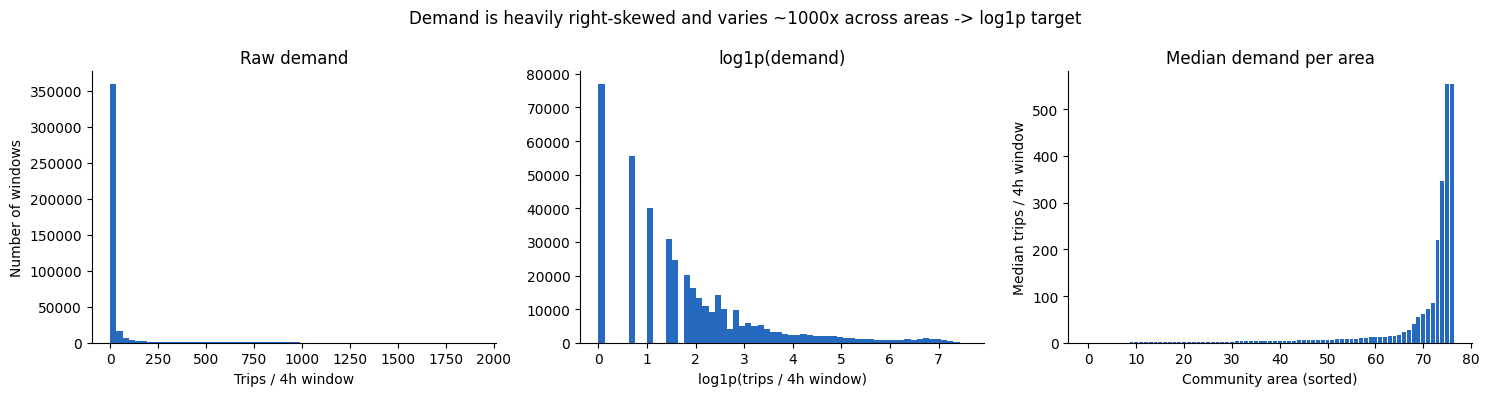

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(panel["count"], bins=60, color=SEQUENTIAL_BLUE)
axes[0].set_title("Raw demand")
axes[0].set_xlabel("Trips / 4h window")
axes[0].set_ylabel("Number of windows")

axes[1].hist(np.log1p(panel["count"]), bins=60, color=SEQUENTIAL_BLUE)
axes[1].set_title("log1p(demand)")
axes[1].set_xlabel("log1p(trips / 4h window)")

area_median_sorted = panel.groupby("community_area")["count"].median().sort_values()
axes[2].bar(range(len(area_median_sorted)), area_median_sorted.to_numpy(), color=SEQUENTIAL_BLUE, width=0.8)
axes[2].set_title("Median demand per area")
axes[2].set_xlabel("Community area (sorted)")
axes[2].set_ylabel("Median trips / 4h window")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Demand is heavily right-skewed and varies ~1000x across areas -> log1p target")
plt.tight_layout()
plt.show()

## 3. Feature Set & Shared Helpers

- 17 exogenous time/weather features + 76 community-area dummies.
- `ColumnTransformer` scales only the continuous features, not the dummies.

In [5]:
FEATURE_COLS = [
    "temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover",
    "hour_sin", "hour_cos", "hour_sin2", "hour_cos2",
    "day_of_week_sin", "day_of_week_cos", "day_of_week_sin2", "day_of_week_cos2",
    "month_sin", "month_cos", "is_weekend", "is_holiday",
]
ALL_COLS = FEATURE_COLS + DUMMY_COLS

preprocess = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS),
    ("area_dummies", "passthrough", DUMMY_COLS),
])

train = panel[panel["timestamp"] < TRAIN_END]
test  = panel[panel["timestamp"] >= TRAIN_END]
y_true = test["count"].to_numpy(dtype=float)
print(f"train={len(train):,} rows   test={len(test):,} rows")


def metrics(y_true, y_pred):
    return {
        "r2":   round(r2_score(y_true, y_pred), 4),
        "mae":  round(mean_absolute_error(y_true, y_pred), 2),
        "rmse": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 2),
    }


# Train-period mean demand per area -- same convention as 03.05's NN notebook (mean, not
# median, unlike AREA_MEDIAN_DEMAND below), so weighted_rmse is directly comparable across
# the two notebooks.
UNIT_WEIGHT = train.groupby("community_area")["count"].mean()
TEST_UNIT_WEIGHTS = test["community_area"].map(UNIT_WEIGHT).fillna(UNIT_WEIGHT.mean()).to_numpy()


def weighted_rmse(y_true, y_pred, weights):
    """Pooled RMSE with each row weighted by its area's train-period mean demand, so errors
    in high-volume areas count more. Complements (not a replacement for) skill_vs_baseline's
    per-area, baseline-relative weighting below -- this one is absolute-scale and pooled,
    like plain RMSE, just demand-weighted instead of uniformly weighted across rows."""
    return float(np.sqrt(np.average((np.asarray(y_true) - np.asarray(y_pred)) ** 2, weights=weights)))


def predict_counts(model, X):
    """Back-transform log-scale predictions to counts, clipped at 0 (and capped pre-expm1
    so an unclipped kernel prediction can't overflow to inf)."""
    y_log = np.clip(model.predict(X), -LOG_PRED_CAP, LOG_PRED_CAP)
    return np.clip(np.expm1(y_log), 0, None)


def per_area_results(test_df, y_pred, group_col="community_area"):
    """One row per spatial unit: MAE/R2/RMSE of the pooled model's predictions for that unit.
    `group_col` generalizes this across resolutions (community area now, census tract in
    section 11) so the same evaluation code is reused rather than duplicated per resolution."""
    tmp = pd.DataFrame({
        group_col: test_df[group_col].to_numpy(),
        "y_true": test_df["count"].to_numpy(dtype=float),
        "y_pred": y_pred,
    })
    rows = [
        {group_col: g, **metrics(g_df["y_true"], g_df["y_pred"])}
        for g, g_df in tmp.groupby(group_col)
    ]
    return pd.DataFrame(rows)


def skill_vs_baseline(results_df, baseline_df=None, group_col="community_area"):
    """Per-unit skill score: 1 - MAE_model / MAE_baseline -- comparable across units of different scale; MAE rather than RMSE so the
    baseline, which predicts the group mean, gets no built-in advantage under the scoring loss).
    `baseline_df` defaults to the community-area `baseline_results` for backward compatibility
    with the community-area cells above; pass the tract-level baseline explicitly at tract
    resolution (section 11)."""
    if baseline_df is None:
        baseline_df = baseline_results
    base = baseline_df[[group_col, "mae"]].rename(columns={"mae": "mae_base"})
    merged = results_df.merge(base, on=group_col)
    return (1 - merged["mae"] / merged["mae_base"]).rename("skill")


AREA_MEDIAN_DEMAND = panel.groupby("community_area")["count"].median().rename("median_demand")


def weighted_skill_vs_baseline(results_df, baseline_df=None, median_demand=None, group_col="community_area"):
    """Demand-weighted mean skill: each unit's skill weighted by its own median demand, so
    high-volume units -- where the fleet is actually deployed -- drive the number. This is the
    headline metric here (business case: the fleet is allocated mostly to high-demand areas).
    The unweighted median (every unit counted equally) is kept as a secondary spatial-coverage
    view.
    `baseline_df`/`median_demand` default to the community-area globals for backward
    compatibility; pass the tract-level equivalents explicitly at tract resolution (section 11).
    """
    if median_demand is None:
        median_demand = AREA_MEDIAN_DEMAND
    skill = skill_vs_baseline(results_df, baseline_df=baseline_df, group_col=group_col)
    weights = results_df[[group_col]].merge(
        median_demand, left_on=group_col, right_index=True
    )["median_demand"].to_numpy()
    return float(np.average(skill.to_numpy(), weights=weights))


def relative_mae(results_df, median_demand=None, group_col="community_area"):
    """MAE normalized by each unit's own median demand (+1, avoids div-by-zero for
    zero-median units) -- an absolute, baseline-free error scale, complementary to skill
    (which is relative to the profile baseline, not to the unit's own demand level). Unlike
    row-level MAPE this can't blow up on zero-demand rows, since it ratios the aggregate MAE
    to the aggregate median, not individual predictions to individual actuals.
    `median_demand` defaults to `AREA_MEDIAN_DEMAND` for backward compatibility; pass the
    tract-level lookup explicitly at tract resolution."""
    if median_demand is None:
        median_demand = AREA_MEDIAN_DEMAND
    demand = results_df[[group_col]].merge(
        median_demand, left_on=group_col, right_index=True
    )["median_demand"].to_numpy()
    return pd.Series(results_df["mae"].to_numpy() / (demand + 1), index=results_df.index, name="relative_mae")


def print_pooled_results(label, pooled_metrics, per_area_df, baseline_df=None, median_demand=None,
                          group_col="community_area", weighted_rmse_value=None):
    w_skill = weighted_skill_vs_baseline(
        per_area_df, baseline_df=baseline_df, median_demand=median_demand, group_col=group_col,
    )
    print(label)
    print(f"  Pooled       : R2={pooled_metrics['r2']:.3f}  MAE={pooled_metrics['mae']:.2f}  "
          f"RMSE={pooled_metrics['rmse']:.2f}  (sanity check only)")
    if weighted_rmse_value is not None:
        print(f"  Weighted RMSE: {weighted_rmse_value:.2f}  (headline)")
    print(f"  Skill        : demand-weighted (headline)={w_skill:+.3f}  "
          f"unweighted median={per_area_df['skill'].median():+.3f}  "
          f"median R2={per_area_df['r2'].median():.3f}  "
          f"(areas with negative skill: {(per_area_df['skill']<0).sum()} of {len(per_area_df)})")

train=337,722 rows   test=69,762 rows


### 3.1 Feature Correlations

- Sanity check before modeling: no pair of the 17 continuous features is near-collinear
  (hour/day-of-week sin-cos pairs are orthogonal by construction).

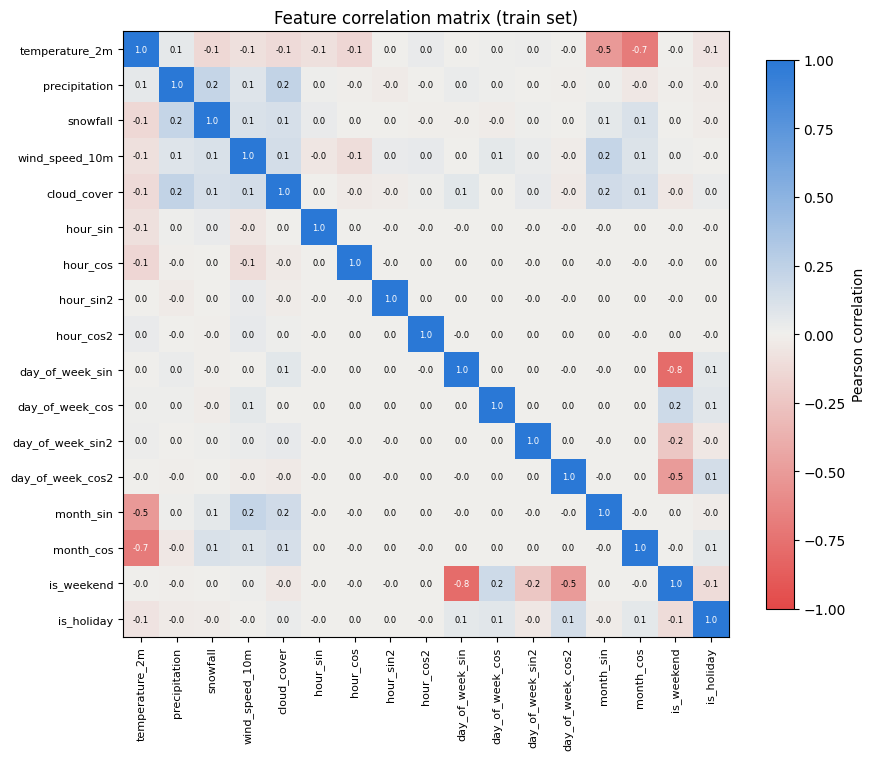

In [6]:
corr = train[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap=DIVERGING_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=90, fontsize=8)
ax.set_yticklabels(FEATURE_COLS, fontsize=8)
for i in range(len(FEATURE_COLS)):
    for j in range(len(FEATURE_COLS)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=6,
                color="white" if abs(val) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Feature correlation matrix (train set)")
plt.tight_layout()
plt.show()

## 4. Profile Baseline

- Train-set mean demand per (hour, weekday, month), computed per area — every area gets its own
  baseline/skill reference, no exclusion. Month is included so the profile captures seasonal
  demand shifts, not just the daily/weekly cycle (matches the NN notebook's baseline bucketing).

Profile baseline, all 77 areas (0s)
  Pooled  : R2=0.933  MAE=9.53  RMSE=37.31  Weighted RMSE=139.02
  Per area: median R2=0.208  median MAE=2.13  median RMSE=2.80  (areas with R2<0: 21 of 77)

Per-area profile-baseline performance (sorted by R2, worst first):
 community_area  median_demand      r2    mae   rmse  relative_mae
             53            7.0 -1.4480   4.26   5.48      0.532500
             37            3.0 -1.4337   2.60   3.11      0.650000
             54            2.0 -1.2346   1.75   2.29      0.583333
             52            1.0 -1.2297   1.29   1.70      0.645000
             55            1.0 -0.5568   1.11   1.51      0.555000
             75            4.0 -0.4158   2.68   3.49      0.536000
             63            0.0 -0.3851   0.44   0.63      0.440000
             12            3.0 -0.3793   1.91   2.40      0.477500
              9            0.0 -0.3735   0.70   0.91      0.700000
             50            3.0 -0.3661   2.10   2.76      0.525000
  

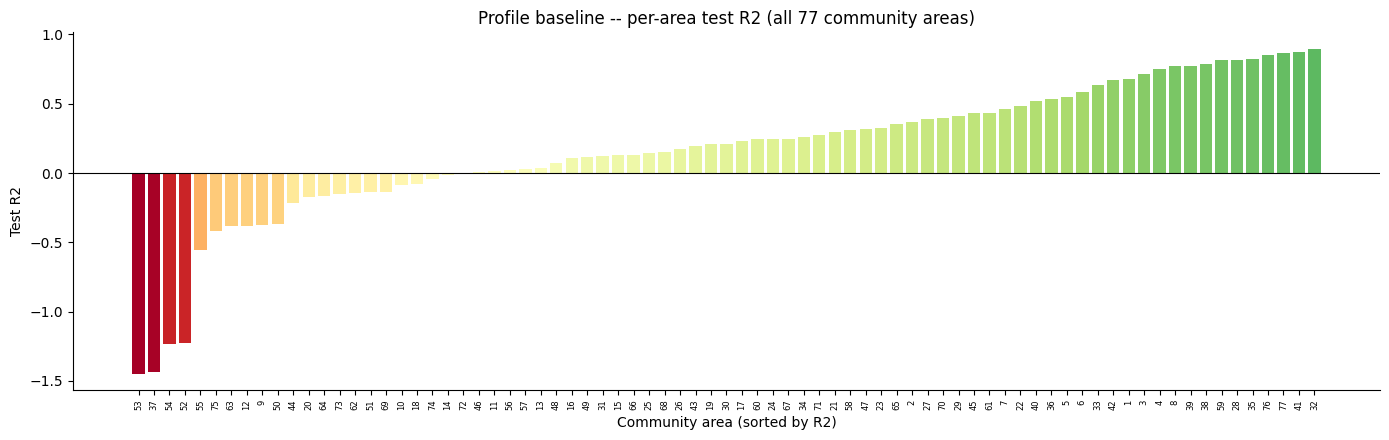

In [7]:
def profile_baseline(panel, groups, group_col="community_area"):
    results = []
    y_true_all, y_pred_all = [], []
    for g in groups:
        df_g = panel[panel[group_col] == g]
        tr = df_g[df_g["timestamp"] < TRAIN_END]
        te = df_g[df_g["timestamp"] >= TRAIN_END]
        profile = tr.groupby(["hour", "day_of_week", "month"])["count"].mean()
        fallback = tr["count"].mean()
        keys = pd.MultiIndex.from_arrays([te["hour"], te["day_of_week"], te["month"]])
        y_pred = profile.reindex(keys).fillna(fallback).to_numpy()
        y_true_ = te["count"].to_numpy(dtype=float)
        results.append({
            group_col: g,
            "median_demand": float(df_g["count"].median()),
            **metrics(y_true_, y_pred),
        })
        y_true_all.append(y_true_)
        y_pred_all.append(y_pred)
    per_group_df = pd.DataFrame(results)
    y_true_concat, y_pred_concat = np.concatenate(y_true_all), np.concatenate(y_pred_all)
    pooled = metrics(y_true_concat, y_pred_concat)
    return per_group_df, pooled, y_true_concat, y_pred_concat


t0 = time.time()
baseline_results, pm_baseline, baseline_y_true, baseline_y_pred = profile_baseline(panel, ALL_AREAS)
baseline_results["community_area"] = baseline_results["community_area"].astype(int)
baseline_results["relative_mae"] = baseline_results["mae"] / (baseline_results["median_demand"] + 1)
fit_time_base = time.time() - t0

print(f"Profile baseline, all 77 areas ({fit_time_base:.0f}s)")
print(f"  Pooled  : R2={pm_baseline['r2']:.3f}  MAE={pm_baseline['mae']:.2f}  RMSE={pm_baseline['rmse']:.2f}  "
      f"Weighted RMSE={weighted_rmse(y_true, baseline_y_pred, TEST_UNIT_WEIGHTS):.2f}")
print(f"  Per area: median R2={baseline_results['r2'].median():.3f}  "
      f"median MAE={baseline_results['mae'].median():.2f}  "
      f"median RMSE={baseline_results['rmse'].median():.2f}  "
      f"(areas with R2<0: {(baseline_results['r2']<0).sum()} of {len(baseline_results)})")

print("\nPer-area profile-baseline performance (sorted by R2, worst first):")
print(baseline_results.sort_values("r2").reset_index(drop=True).to_string(index=False))

# Diverging (R2 can be negative or positive) colouring, same RdYlGn scale used for the
# skill map further down, so the two figures read consistently.
plot_df = baseline_results.sort_values("r2").reset_index(drop=True)
vlim = max(0.5, plot_df["r2"].abs().max())
colors = plt.cm.RdYlGn((plot_df["r2"] + vlim) / (2 * vlim))

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(range(len(plot_df)), plot_df["r2"], color=colors, width=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df["community_area"], rotation=90, fontsize=6)
ax.set_xlabel("Community area (sorted by R2)")
ax.set_ylabel("Test R2")
ax.set_title("Profile baseline -- per-area test R2 (all 77 community areas)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 4.1 Baseline Performance

Actual vs. predicted counts for the top 3 and bottom 3 community areas (by median demand
in the eval week), same test week and plotting convention used later for model comparisons.

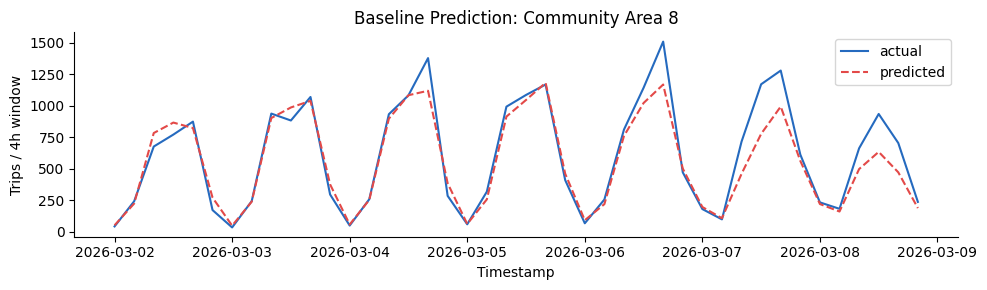

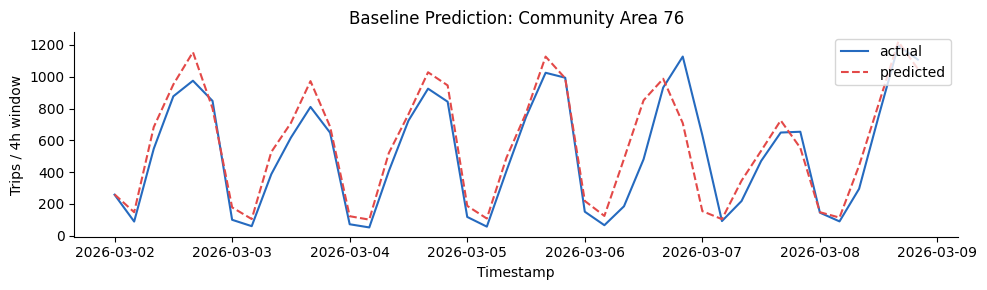

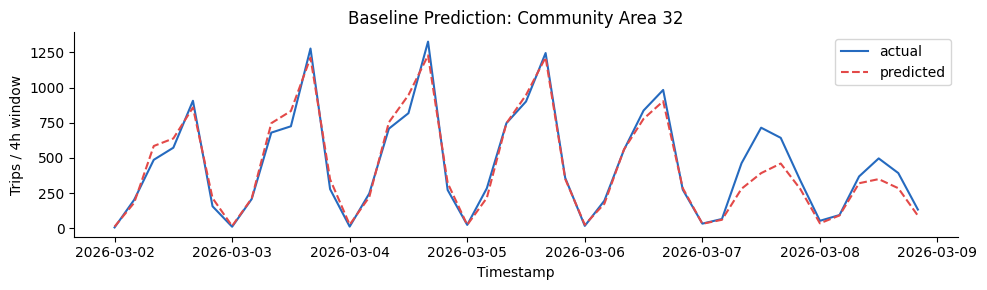

In [8]:
# Show actual vs predicted counts for the top 3 community areas for a week in the test set
eval_mask = (test["timestamp"] >= EVAL_WEEK_START) & (test["timestamp"] < EVAL_WEEK_END)
test_plot = test[eval_mask].reset_index(drop=True)
test_plot_pred_base = baseline_y_pred[eval_mask.to_numpy()]

# Get the top 3 community areas by median demand in the test set
top_3_areas = test_plot.groupby("community_area")["count"].median().sort_values(ascending=False).head(3).index

for area in top_3_areas:
    mask = (test_plot["community_area"] == area).to_numpy()
    area_val = test_plot[mask]
    area_pred = test_plot_pred_base[mask]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=SEQUENTIAL_BLUE)
    ax.plot(area_val["timestamp"], area_pred, label="predicted", color="#e34948", linestyle="--")
    ax.set_title(f"Baseline Prediction: Community Area {area}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Trips / 4h window")
    ax.legend(loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


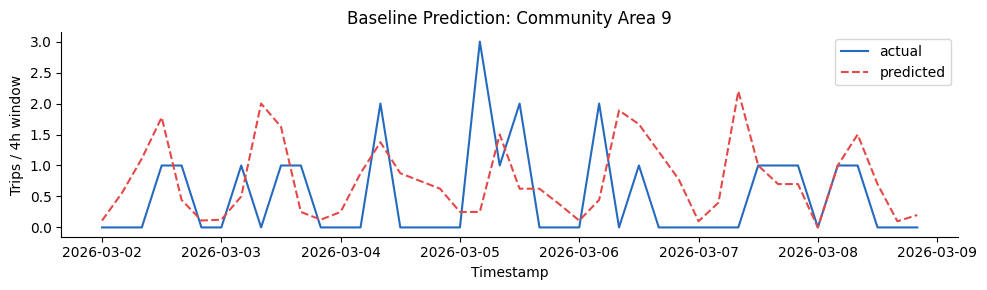

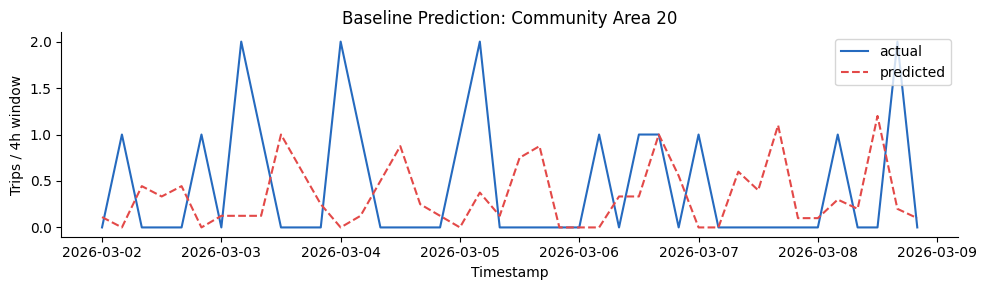

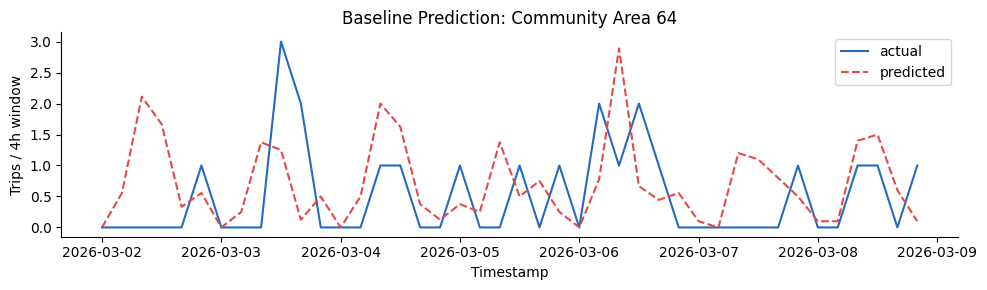

In [9]:
# Show actual vs predicted counts for the bottom 3 community areas for the same test week

bottom_3_areas = test_plot.groupby("community_area")["count"].median().sort_values(ascending=True).head(3).index

for area in bottom_3_areas:
    mask = (test_plot["community_area"] == area).to_numpy()
    area_val = test_plot[mask]
    area_pred = test_plot_pred_base[mask]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=SEQUENTIAL_BLUE)
    ax.plot(area_val["timestamp"], area_pred, label="predicted", color="#e34948", linestyle="--")
    ax.set_title(f"Baseline Prediction: Community Area {area}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Trips / 4h window")
    ax.legend(loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


## 5. Pooled LinearSVR — No Kernel

- One `LinearSVR`, fit on all 337,722 training rows (all 77 areas), evaluated pooled and
  per area.

In [10]:
t0 = time.time()
linear_model = Pipeline([
    ("prep", preprocess),
    ("svm", LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=SEED)),
])
linear_model.fit(train[ALL_COLS], np.log1p(train["count"]))
y_pred_linear = predict_counts(linear_model, test[ALL_COLS])
pm_linear = metrics(y_true, y_pred_linear)
res_linear = per_area_results(test, y_pred_linear)
res_linear["skill"] = skill_vs_baseline(res_linear)
res_linear["relative_mae"] = relative_mae(res_linear)
fit_time_linear = time.time() - t0

print_pooled_results(f"Pooled LinearSVR ({fit_time_linear:.0f}s)", pm_linear, res_linear,
                     weighted_rmse_value=weighted_rmse(y_true, y_pred_linear, TEST_UNIT_WEIGHTS))

Pooled LinearSVR (213s)
  Pooled       : R2=0.778  MAE=15.44  RMSE=67.64  (sanity check only)
  Weighted RMSE: 254.94  (headline)
  Skill        : demand-weighted (headline)=-0.827  unweighted median=-0.017  median R2=0.259  (areas with negative skill: 40 of 77)


### 5.1 Feature Importance (LinearSVR Coefficients)

- `LinearSVR` is linear, so its coefficients on the standardized continuous features are
  directly interpretable as feature importance (larger |coefficient| = bigger effect on
  log-scale demand).
- Community-area dummy coefficients are a fixed log-demand offset per area relative to the
  reference area (area 1) -- shown separately (top/bottom 5 of 76), not comparable in
  magnitude to the continuous-feature coefficients since dummies aren't standardized.

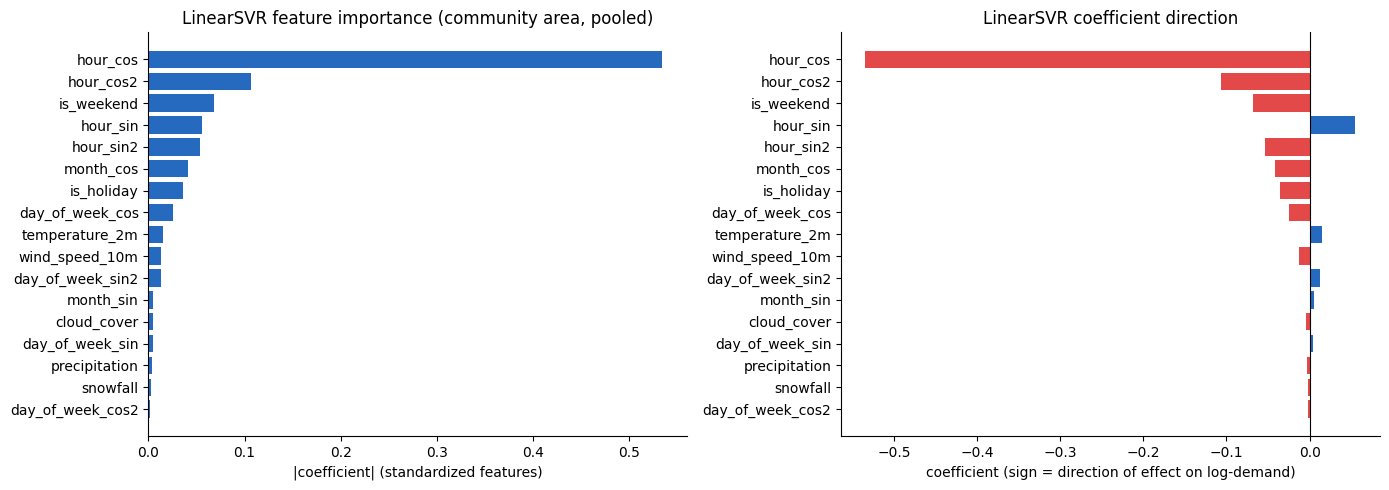

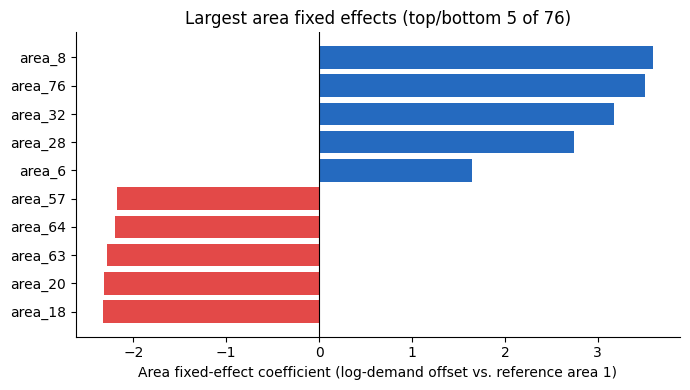

In [11]:
coefs = linear_model.named_steps["svm"].coef_
feature_coefs = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": coefs[:len(FEATURE_COLS)],
    "importance": np.abs(coefs[:len(FEATURE_COLS)]),
}).sort_values("importance")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(feature_coefs["feature"], feature_coefs["importance"], color=SEQUENTIAL_BLUE)
axes[0].set_xlabel("|coefficient| (standardized features)")
axes[0].set_title("LinearSVR feature importance (community area, pooled)")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].barh(feature_coefs["feature"], feature_coefs["coefficient"],
             color=[SEQUENTIAL_BLUE if c >= 0 else "#e34948" for c in feature_coefs["coefficient"]])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("coefficient (sign = direction of effect on log-demand)")
axes[1].set_title("LinearSVR coefficient direction")
axes[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Community-area fixed effects: which areas get the biggest adjustment vs. the reference area
area_coefs = pd.Series(coefs[len(FEATURE_COLS):], index=DUMMY_COLS).sort_values()
top_bottom = pd.concat([area_coefs.head(5), area_coefs.tail(5)])

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top_bottom.index, top_bottom.to_numpy(),
        color=[SEQUENTIAL_BLUE if c >= 0 else "#e34948" for c in top_bottom])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Area fixed-effect coefficient (log-demand offset vs. reference area 1)")
ax.set_title("Largest area fixed effects (top/bottom 5 of 76)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 5.2 Demand-Weighted LinearSVR

- `LinearSVR`'s demand-weighted skill is strongly negative (-0.75, section 8) -- shared
  coefficients end up fit mostly to the low-demand majority since every area contributes
  equally many rows.
- **Fix tried**: refit with `sample_weight = sqrt(median_demand + 1)` per row, so the loss
  prioritizes high-demand areas the way the model is judged.

Pooled LinearSVR, demand-weighted (1253s)
  Pooled       : R2=0.814  MAE=14.35  RMSE=61.94  (sanity check only)
  Weighted RMSE: 231.91  (headline)
  Skill        : demand-weighted (headline)=-0.675  unweighted median=-0.052  median R2=0.220  (areas with negative skill: 53 of 77)


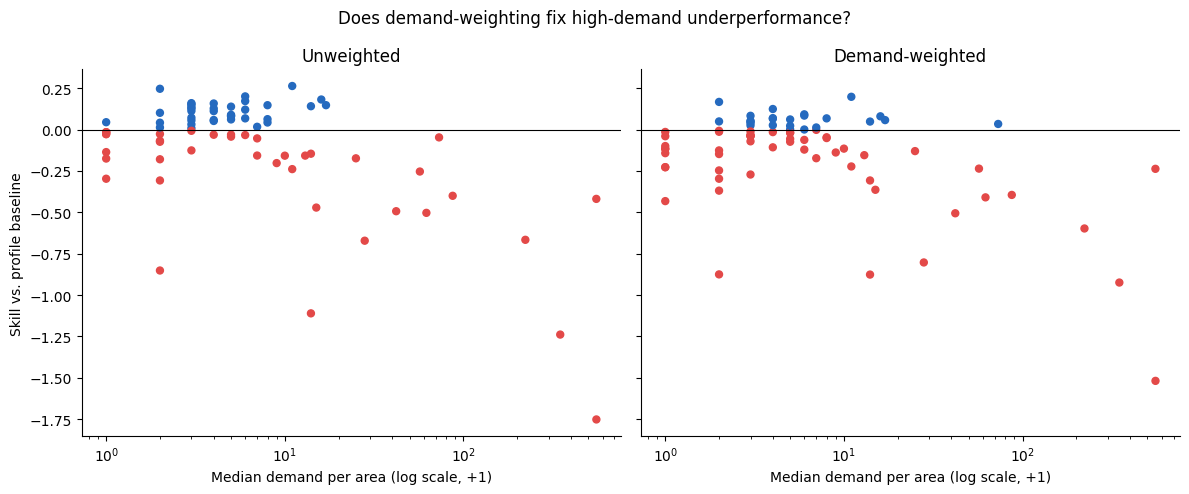

In [12]:
train_weight = np.sqrt(train["community_area"].map(AREA_MEDIAN_DEMAND) + 1)

t0 = time.time()
linear_model_weighted = Pipeline([
    ("prep", preprocess),
    ("svm", LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=SEED)),
])
linear_model_weighted.fit(train[ALL_COLS], np.log1p(train["count"]), svm__sample_weight=train_weight)
y_pred_linear_weighted = predict_counts(linear_model_weighted, test[ALL_COLS])
pm_linear_weighted = metrics(y_true, y_pred_linear_weighted)
res_linear_weighted = per_area_results(test, y_pred_linear_weighted)
res_linear_weighted["skill"] = skill_vs_baseline(res_linear_weighted)
res_linear_weighted["relative_mae"] = relative_mae(res_linear_weighted)
fit_time_linear_weighted = time.time() - t0

print_pooled_results(f"Pooled LinearSVR, demand-weighted ({fit_time_linear_weighted:.0f}s)", pm_linear_weighted, res_linear_weighted,
                     weighted_rmse_value=weighted_rmse(y_true, y_pred_linear_weighted, TEST_UNIT_WEIGHTS))

# Before/after: does weighting fix the high-demand underperformance?
before = res_linear.merge(AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True)
after = res_linear_weighted.merge(AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, df, title in [(axes[0], before, "Unweighted"), (axes[1], after, "Demand-weighted")]:
    colors = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in df["skill"]]
    ax.scatter(df["median_demand"] + 1, df["skill"], color=colors, s=25)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("Median demand per area (log scale, +1)")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Skill vs. profile baseline")
plt.suptitle("Does demand-weighting fix high-demand underperformance?")
plt.tight_layout()
plt.show()

### 5.3 Outcome: Weighting Alone Doesn't Solve It

| | Unweighted | Weighted |
|---|---|---|
| Demand-weighted skill | -0.75 | -0.61 |
| Unweighted median skill | -0.03 | -0.12 |
| Negative-skill areas | 48/77 | 67/77 |

- Weighting improves the headline metric but makes most areas worse -- a trade-off, not a fix.
- **Likely cause**: `expm1` amplifies log-scale error multiplicatively, so a small
  `log1p`-space miss becomes a large absolute error exactly where demand is largest -- the
  baseline never pays this penalty, predicting directly in raw-count space.
- **Decision**: unweighted `LinearSVR` (full data) is the SVM entry going forward -- not
  because it solves the problem, but because weighting doesn't either. Demand-tiering and
  per-area models are explored separately in section 9, not adopted as the default here.

## 6. Kernel Comparison

- Exact kernel SVR is O(n^2)-O(n^3) in training rows — infeasible on 337,722 full rows.
- Compared on a **10,000-row random subsample**, evaluated against the full test set.
- **Informational only** — section 7 shows subsample-tuned results are unreliable.

In [13]:
rng = np.random.RandomState(SEED)
sub_idx = rng.choice(train.index, size=10000, replace=False)
train_sub = train.loc[sub_idx]

candidates = {
    "no kernel (LinearSVR)": LinearSVR(C=1.0, epsilon=0.1, max_iter=10000, random_state=SEED),
    "linear (SVR)":          SVR(kernel="linear",  C=100, epsilon=0.1),
    "poly, degree 2":        SVR(kernel="poly",    degree=2, C=100, gamma="scale", epsilon=0.1),
    "rbf":                   SVR(kernel="rbf",     C=100, gamma="scale", epsilon=0.1),
    "sigmoid":               SVR(kernel="sigmoid", C=100, gamma="scale", epsilon=0.1),
}

kernel_rows = []
for name, svm in candidates.items():
    t0 = time.time()
    m = Pipeline([("prep", preprocess), ("svm", svm)])
    m.fit(train_sub[ALL_COLS], np.log1p(train_sub["count"]))
    y_pred = predict_counts(m, test[ALL_COLS])
    kernel_rows.append({"kernel": name, **metrics(y_true, y_pred), "fit_seconds": round(time.time() - t0, 1)})

kernel_df = pd.DataFrame(kernel_rows).sort_values("r2", ascending=False)
print("Kernel comparison -- 10,000-row train subsample, full test set, pooled metrics:")
print(kernel_df.to_string(index=False))


Kernel comparison -- 10,000-row train subsample, full test set, pooled metrics:
               kernel            r2          mae         rmse  fit_seconds
       poly, degree 2  8.964000e-01        11.28        46.25        267.7
         linear (SVR)  7.817000e-01        15.25        67.12        512.5
no kernel (LinearSVR)  7.782000e-01        15.32        67.66          0.8
                  rbf  7.482000e-01        15.32        72.08        192.8
              sigmoid -5.876136e+12 250041722.44 348234749.14         63.2


- **Methodological trap, caught early**: scaling the dummy columns flipped which kernel
  looked best — RBF looked best (R2=0.85) with dummies scaled; poly degree 2 looked best
  (R2=0.88) once dummies were left unscaled (RBF dropped to R2=0.74).
- RBF's distance-based kernel was dominated by the inflated dummy scale; poly's dot-product
  kernel was far less sensitive.
- Sigmoid is unstable regardless of scaling.

## 7. Hyperparameter Tuning — GridSearchCV

- Tuning poly (the naive section-6 winner) properly with `GridSearchCV` + `KFold(3, shuffled)`,
  same 20,000-row budget, a different draw than section 6.
- **`KFold`, not `TimeSeriesSplit`**: no lagged-demand features means no autoregressive
  leakage risk a chronological split would guard against, so shuffled folds are used instead
  -- each fold gets an even mix of seasons.

In [14]:
# KFold, not TimeSeriesSplit: no lagged/historical-demand features means no autoregressive
# leakage risk, so a chronological split isn't required -- and shuffled folds give each fold
# an even mix of seasons instead of the growing-window bias TimeSeriesSplit would introduce.
kfold = KFold(n_splits=3, shuffle=True, random_state=SEED)
rng2 = np.random.RandomState(SEED)
sub_idx2 = rng2.choice(train.index, size=10000, replace=False)
train_sub2 = train.loc[sub_idx2]

poly_param_grid = {"svm__C": [1, 10, 100], "svm__degree": [2, 3], "svm__gamma": ["scale"]}
t0 = time.time()
gs_poly = GridSearchCV(
    Pipeline([("prep", preprocess), ("svm", SVR(kernel="poly", epsilon=0.1))]),
    poly_param_grid, cv=kfold, scoring="r2", n_jobs=-1,
)
gs_poly.fit(train_sub2[FEATURE_COLS + DUMMY_COLS], np.log1p(train_sub2["count"]))
y_pred_poly = predict_counts(gs_poly, test[ALL_COLS])
pm_poly = metrics(y_true, y_pred_poly)
res_poly = per_area_results(test, y_pred_poly)
res_poly["skill"] = skill_vs_baseline(res_poly)
res_poly["relative_mae"] = relative_mae(res_poly)
fit_time_poly = time.time() - t0

print(f"Tuned poly ({fit_time_poly:.0f}s): best_params={gs_poly.best_params_}  "
      f"best_cv_r2={gs_poly.best_score_:.3f}")
print_pooled_results("", pm_poly, res_poly,
                     weighted_rmse_value=weighted_rmse(y_true, y_pred_poly, TEST_UNIT_WEIGHTS))

rbf_param_grid = {"svm__C": [10, 100], "svm__gamma": ["scale", 0.01]}
t0 = time.time()
gs_rbf = GridSearchCV(
    Pipeline([("prep", preprocess), ("svm", SVR(kernel="rbf", epsilon=0.1))]),
    rbf_param_grid, cv=kfold, scoring="r2", n_jobs=-1,
)
gs_rbf.fit(train_sub2[FEATURE_COLS + DUMMY_COLS], np.log1p(train_sub2["count"]))
y_pred_rbf = predict_counts(gs_rbf, test[ALL_COLS])
pm_rbf = metrics(y_true, y_pred_rbf)
res_rbf = per_area_results(test, y_pred_rbf)
res_rbf["skill"] = skill_vs_baseline(res_rbf)
res_rbf["relative_mae"] = relative_mae(res_rbf)
fit_time_rbf = time.time() - t0

print(f"\nTuned RBF ({fit_time_rbf:.0f}s): best_params={gs_rbf.best_params_}  "
      f"best_cv_r2={gs_rbf.best_score_:.3f}")
print_pooled_results("", pm_rbf, res_rbf,
                     weighted_rmse_value=weighted_rmse(y_true, y_pred_rbf, TEST_UNIT_WEIGHTS))

Tuned poly (998s): best_params={'svm__C': 100, 'svm__degree': 2, 'svm__gamma': 'scale'}  best_cv_r2=0.865

  Pooled       : R2=0.896  MAE=11.28  RMSE=46.25  (sanity check only)
  Weighted RMSE: 171.71  (headline)
  Skill        : demand-weighted (headline)=-0.221  unweighted median=-0.049  median R2=0.095  (areas with negative skill: 49 of 77)

Tuned RBF (1037s): best_params={'svm__C': 100, 'svm__gamma': 0.01}  best_cv_r2=0.891

  Pooled       : R2=0.892  MAE=11.17  RMSE=47.17  (sanity check only)
  Weighted RMSE: 176.93  (headline)
  Skill        : demand-weighted (headline)=-0.232  unweighted median=-0.027  median R2=0.131  (areas with negative skill: 46 of 77)


- CV tracks test performance closely: poly `best_cv_r2=0.865` -> **pooled test R2=0.896**;
  RBF `best_cv_r2=0.891` -> **pooled test R2=0.892**.
- But pooled R2 isn't the headline metric here (see Validation Strategy) -- per area, both
  still lose to the profile baseline on demand-weighted skill (poly -0.221, RBF -0.232;
  negative for 49/77 and 46/77 areas respectively): the strong pooled R2 is driven by the
  handful of highest-volume areas, not broad per-area accuracy.
- **Conclusion**: kernel-SVR tuning with `KFold` gives a trustworthy CV signal, but it still
  doesn't beat the baseline where it matters (per area). `LinearSVR` (full data, no
  subsampling) remains the model carried into section 8.

## 8. Results — Model Comparison

- None of the `LinearSVR` variants beat the profile baseline on demand-weighted skill (5.1-5.3)
  -- plain **unweighted `LinearSVR`** (per 5.3) is used below as the SVM entry.
- Tuned kernel models are shown for completeness, not as an alternative recommendation.

Two headline metrics: demand-weighted skill (relative to baseline, comparable across
resolutions) and weighted RMSE (absolute trips/window, comparable against the NN
notebooks). Unweighted median skill and relative MAE are supporting detail.
                           Model  Demand-weighted skill  Median skill  Weighted RMSE  Median relative MAE  Pooled R2  Median R2/area
                Profile baseline                  0.000         0.000        139.015                0.423      0.933           0.208
LinearSVR (full data, no kernel)                 -0.827        -0.017        254.940                0.432      0.778           0.259
     LinearSVR (demand-weighted)                 -0.675        -0.052        231.913                0.447      0.814           0.220
      RBF, tuned (10k subsample)                 -0.232        -0.027        176.933                0.428      0.892           0.131
     Poly, tuned (10k subsample)                 -0.221        -0.049        171.708         

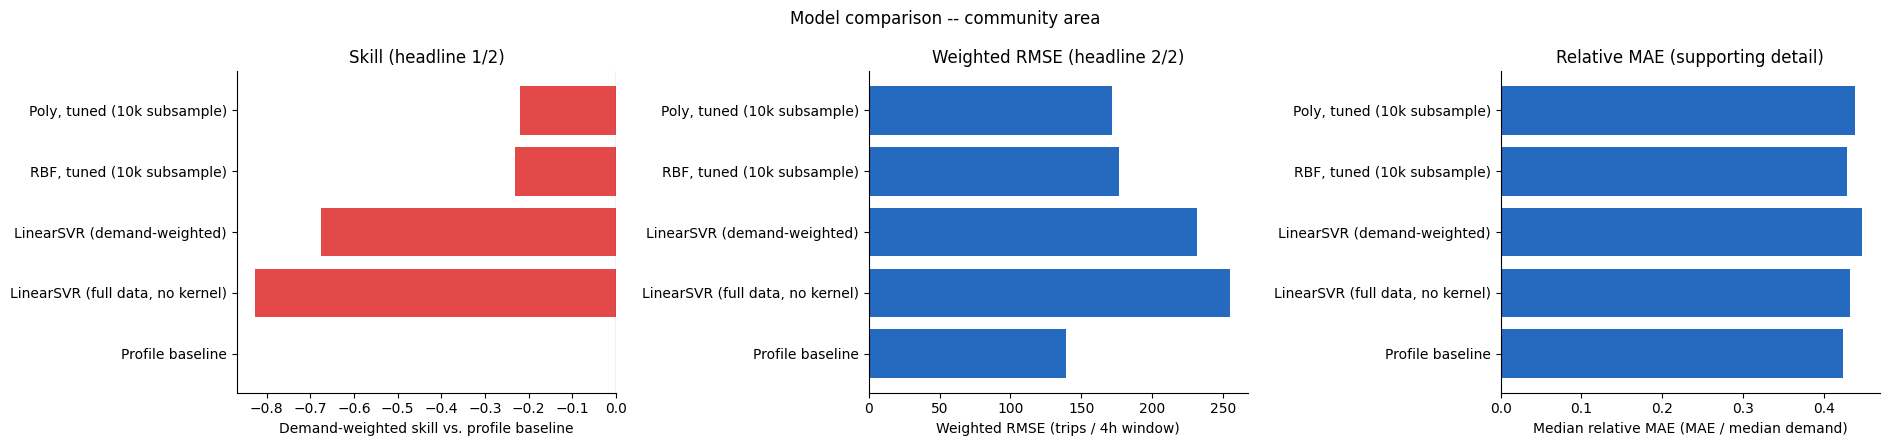

In [15]:
comparison_df = pd.DataFrame([
    {"Model": "Profile baseline", "Demand-weighted skill": 0.000, "Median skill": 0.000,
     "Weighted RMSE": weighted_rmse(y_true, baseline_y_pred, TEST_UNIT_WEIGHTS),
     "Median relative MAE": baseline_results["relative_mae"].median(),
     "Pooled R2": pm_baseline["r2"], "Median R2/area": baseline_results["r2"].median()},
    {"Model": "LinearSVR (full data, no kernel)",
     "Demand-weighted skill": weighted_skill_vs_baseline(res_linear), "Median skill": res_linear["skill"].median(),
     "Weighted RMSE": weighted_rmse(y_true, y_pred_linear, TEST_UNIT_WEIGHTS),
     "Median relative MAE": res_linear["relative_mae"].median(),
     "Pooled R2": pm_linear["r2"], "Median R2/area": res_linear["r2"].median()},
    {"Model": "LinearSVR (demand-weighted)",
     "Demand-weighted skill": weighted_skill_vs_baseline(res_linear_weighted), "Median skill": res_linear_weighted["skill"].median(),
     "Weighted RMSE": weighted_rmse(y_true, y_pred_linear_weighted, TEST_UNIT_WEIGHTS),
     "Median relative MAE": res_linear_weighted["relative_mae"].median(),
     "Pooled R2": pm_linear_weighted["r2"], "Median R2/area": res_linear_weighted["r2"].median()},
    {"Model": "RBF, tuned (10k subsample)",
     "Demand-weighted skill": weighted_skill_vs_baseline(res_rbf), "Median skill": res_rbf["skill"].median(),
     "Weighted RMSE": weighted_rmse(y_true, y_pred_rbf, TEST_UNIT_WEIGHTS),
     "Median relative MAE": res_rbf["relative_mae"].median(),
     "Pooled R2": pm_rbf["r2"], "Median R2/area": res_rbf["r2"].median()},
    {"Model": "Poly, tuned (10k subsample)",
     "Demand-weighted skill": weighted_skill_vs_baseline(res_poly), "Median skill": res_poly["skill"].median(),
     "Weighted RMSE": weighted_rmse(y_true, y_pred_poly, TEST_UNIT_WEIGHTS),
     "Median relative MAE": res_poly["relative_mae"].median(),
     "Pooled R2": pm_poly["r2"], "Median R2/area": res_poly["r2"].median()},
]).round(3)
print("Two headline metrics: demand-weighted skill (relative to baseline, comparable across")
print("resolutions) and weighted RMSE (absolute trips/window, comparable against the NN")
print("notebooks). Unweighted median skill and relative MAE are supporting detail.")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))
chart_df = comparison_df.set_index("Model")["Demand-weighted skill"]
colors_cmp = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in chart_df]
axes[0].barh(chart_df.index, chart_df.to_numpy(), color=colors_cmp)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Demand-weighted skill vs. profile baseline")
axes[0].set_title("Skill (headline 1/2)")
axes[0].spines[["top", "right"]].set_visible(False)

wrmse_df = comparison_df.set_index("Model")["Weighted RMSE"]
axes[1].barh(wrmse_df.index, wrmse_df.to_numpy(), color=SEQUENTIAL_BLUE)
axes[1].set_xlabel("Weighted RMSE (trips / 4h window)")
axes[1].set_title("Weighted RMSE (headline 2/2)")
axes[1].spines[["top", "right"]].set_visible(False)

rmae_df = comparison_df.set_index("Model")["Median relative MAE"]
axes[2].barh(rmae_df.index, rmae_df.to_numpy(), color=SEQUENTIAL_BLUE)
axes[2].set_xlabel("Median relative MAE (MAE / median demand)")
axes[2].set_title("Relative MAE (supporting detail)")
axes[2].spines[["top", "right"]].set_visible(False)
plt.suptitle("Model comparison -- community area")
plt.tight_layout()
plt.show()

### 8.0 Actual vs. Predicted (Test Set)

- Same five models as the comparison table above, same test set, same axes -- a tighter
  cluster along the dashed diagonal means better predictions.
- Plotted on `log1p` scale (a 5,000-point random sample, for a readable scatter): demand spans
  ~1000x across rows, so a raw-scale plot would be unreadable.

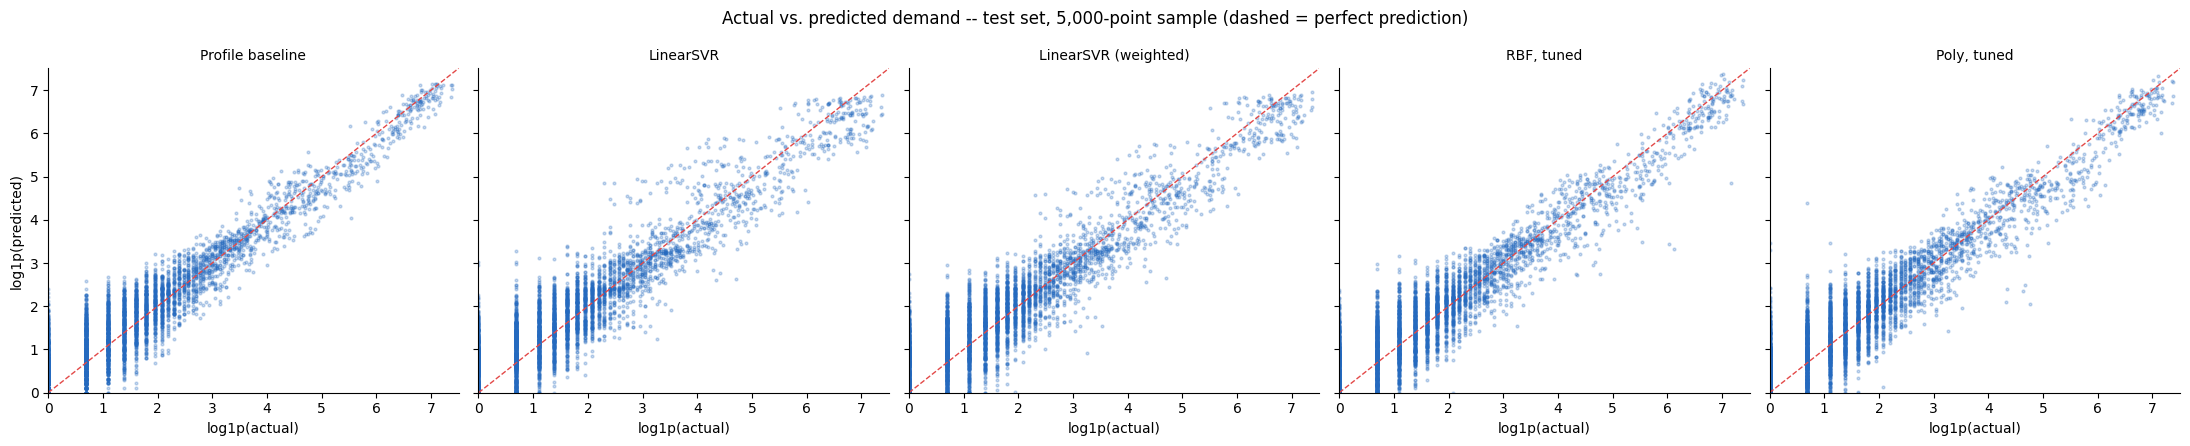

In [16]:
models_to_plot = [
    ("Profile baseline", baseline_y_pred),
    ("LinearSVR", y_pred_linear),
    ("LinearSVR (weighted)", y_pred_linear_weighted),
    ("RBF, tuned", y_pred_rbf),
    ("Poly, tuned", y_pred_poly),
]

rng_viz = np.random.RandomState(0)
sample_n = min(5000, len(y_true))
sample_idx = rng_viz.choice(len(y_true), size=sample_n, replace=False)
log_true = np.log1p(y_true)
lims = [0, log_true.max()]

fig, axes = plt.subplots(1, len(models_to_plot), figsize=(22, 4.5), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, models_to_plot):
    log_pred = np.log1p(y_pred)
    ax.scatter(log_true[sample_idx], log_pred[sample_idx], s=4, alpha=0.25, color=SEQUENTIAL_BLUE)
    ax.plot(lims, lims, color="#e34948", linewidth=1, linestyle="--")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("log1p(actual)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("log1p(predicted)")
plt.suptitle(f"Actual vs. predicted demand -- test set, {sample_n:,}-point sample "
             f"(dashed = perfect prediction)")
plt.tight_layout()
plt.show()

### 8.1 Per-Area Performance

- **Two complementary scores**, both comparable across areas of very different demand:
  - **Skill** -- relative to the profile baseline (competitive: does the model beat a smart
    per-area baseline?).
  - **Relative MAE** (`mae / (median_demand + 1)`) -- absolute, no baseline involved (how
    big are the errors relative to what actually happens in that area?).
- Shown for the plain **unweighted LinearSVR** (per 5.3). The two metrics
  don't have to agree -- an area can look bad on one and fine on the other.

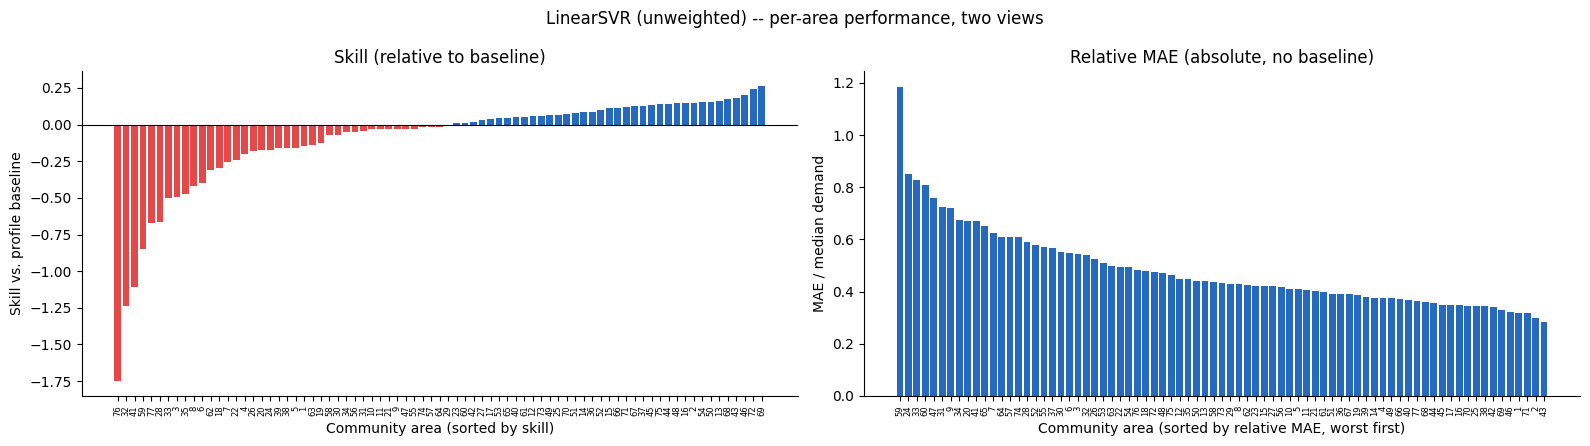

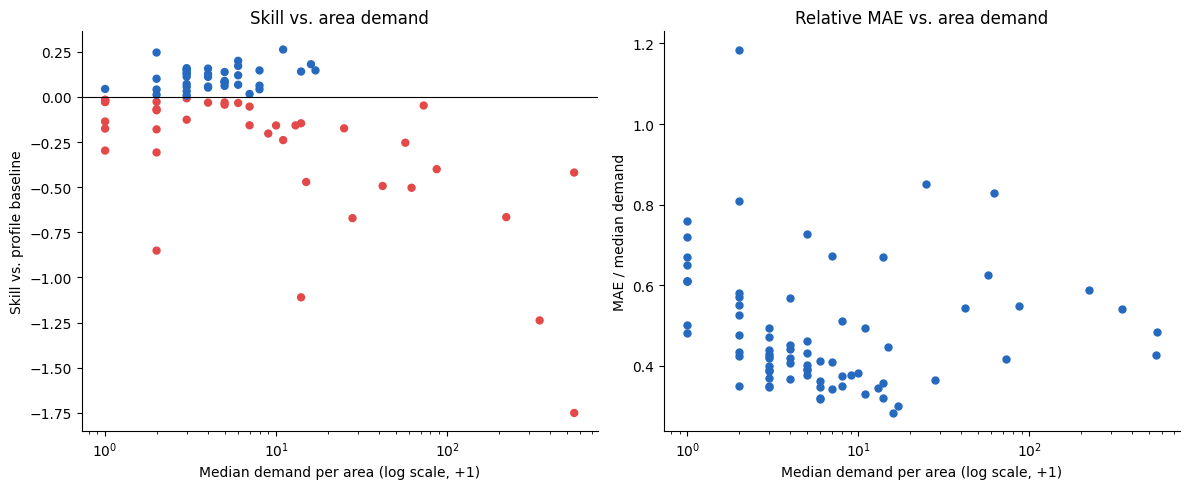

In [17]:
res_linear_by_skill = res_linear.merge(
    AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True
).sort_values("skill").reset_index(drop=True)
colors_skill = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in res_linear_by_skill["skill"]]

res_linear_by_rmae = res_linear.merge(
    AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True
).sort_values("relative_mae", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
axes[0].bar(range(len(res_linear_by_skill)), res_linear_by_skill["skill"], color=colors_skill, width=0.8)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(range(len(res_linear_by_skill)))
axes[0].set_xticklabels(res_linear_by_skill["community_area"], rotation=90, fontsize=6)
axes[0].set_xlabel("Community area (sorted by skill)")
axes[0].set_ylabel("Skill vs. profile baseline")
axes[0].set_title("Skill (relative to baseline)")

axes[1].bar(range(len(res_linear_by_rmae)), res_linear_by_rmae["relative_mae"], color=SEQUENTIAL_BLUE, width=0.8)
axes[1].set_xticks(range(len(res_linear_by_rmae)))
axes[1].set_xticklabels(res_linear_by_rmae["community_area"], rotation=90, fontsize=6)
axes[1].set_xlabel("Community area (sorted by relative MAE, worst first)")
axes[1].set_ylabel("MAE / median demand")
axes[1].set_title("Relative MAE (absolute, no baseline)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("LinearSVR (unweighted) -- per-area performance, two views")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(res_linear_by_skill["median_demand"] + 1, res_linear_by_skill["skill"], color=colors_skill, s=25)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xscale("log")
axes[0].set_xlabel("Median demand per area (log scale, +1)")
axes[0].set_ylabel("Skill vs. profile baseline")
axes[0].set_title("Skill vs. area demand")

axes[1].scatter(res_linear_by_rmae["median_demand"] + 1, res_linear_by_rmae["relative_mae"], color=SEQUENTIAL_BLUE, s=25)
axes[1].set_xscale("log")
axes[1].set_xlabel("Median demand per area (log scale, +1)")
axes[1].set_ylabel("MAE / median demand")
axes[1].set_title("Relative MAE vs. area demand")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Per-area skill map for `LinearSVR` (plain, unweighted, full pooled data) -- no areas excluded.

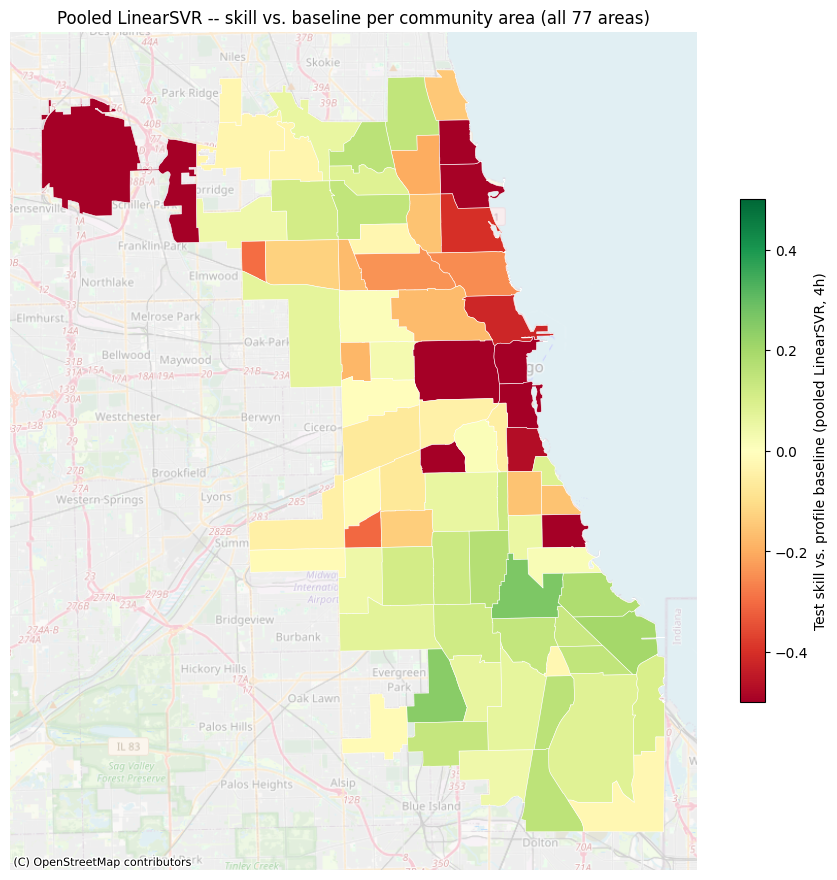

In [18]:
community_areas_gdf = gpd.read_file(COMMUNITY_AREAS_PATH)
community_areas_gdf["area_numbe"] = community_areas_gdf["area_numbe"].astype(int)

gdf_skill = community_areas_gdf.merge(
    res_linear[["community_area", "skill"]],
    left_on="area_numbe", right_on="community_area", how="left",
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))
gdf_skill.plot(ax=ax, column="skill", cmap="RdYlGn", vmin=-0.5, vmax=0.5, legend=True,
               legend_kwds={"label": "Test skill vs. profile baseline (pooled LinearSVR, 4h)", "shrink": 0.6},
               edgecolor="white", linewidth=0.4)
ctx.add_basemap(ax, crs=gdf_skill.crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.35)
ax.set_title("Pooled LinearSVR -- skill vs. baseline per community area (all 77 areas)")
ax.axis("off")
plt.tight_layout()
plt.show()

### 8.2 Top 3 / Bottom 3 Areas -- All Models

Actual vs. all five models for the top-3 and bottom-3 areas (by median demand), same
eval week used for the baseline-only view in section 4.1 -- now with every model overlaid
so the comparison table's numbers are visible as shapes, not just numbers.

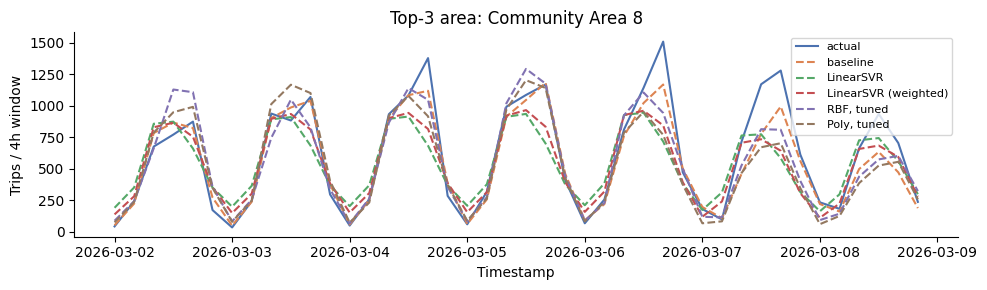

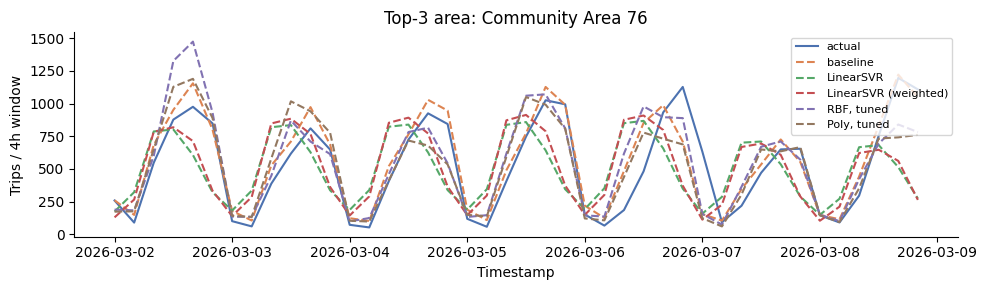

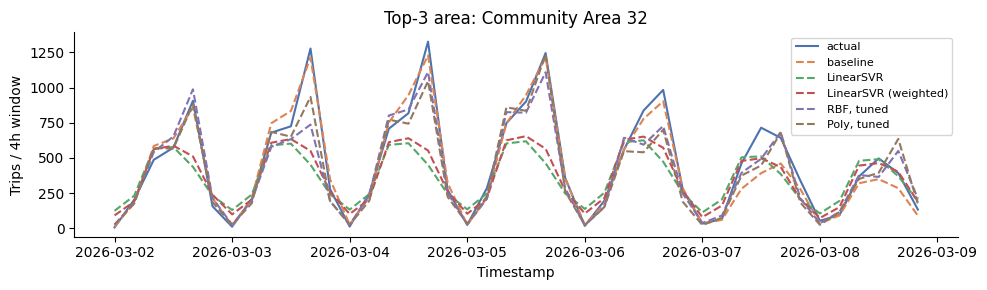

In [19]:
# Same eval_mask/test_plot as section 4.1 -- slice every other model's predictions the same way.
test_plot_pred_linear          = y_pred_linear[eval_mask.to_numpy()]
test_plot_pred_linear_weighted = y_pred_linear_weighted[eval_mask.to_numpy()]
test_plot_pred_rbf             = y_pred_rbf[eval_mask.to_numpy()]
test_plot_pred_poly            = y_pred_poly[eval_mask.to_numpy()]

models_to_plot_ts = [
    ("baseline", test_plot_pred_base),
    ("LinearSVR", test_plot_pred_linear),
    ("LinearSVR (weighted)", test_plot_pred_linear_weighted),
    ("RBF, tuned", test_plot_pred_rbf),
    ("Poly, tuned", test_plot_pred_poly),
]


def plot_area_all_models(areas, title_prefix):
    for area in areas:
        mask = (test_plot["community_area"] == area).to_numpy()
        area_val = test_plot[mask]

        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=CATEGORICAL_COLORS[0])
        for i, (name, y_pred) in enumerate(models_to_plot_ts):
            ax.plot(area_val["timestamp"], y_pred[mask], label=name,
                    color=CATEGORICAL_COLORS[i + 1], linestyle="--")
        ax.set_title(f"{title_prefix}: Community Area {area}")
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Trips / 4h window")
        ax.legend(loc="upper right", fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.show()


plot_area_all_models(top_3_areas, "Top-3 area")


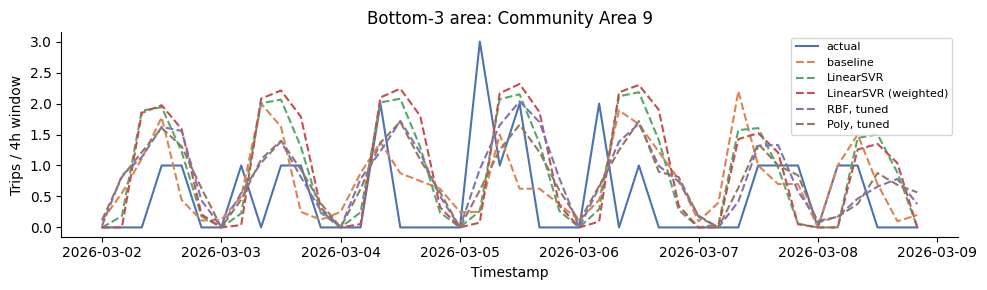

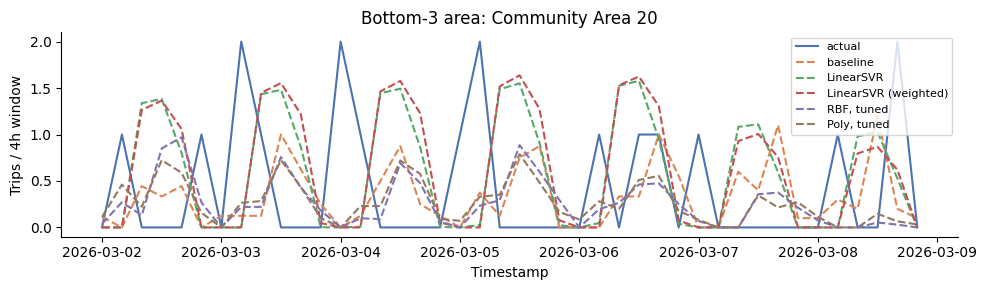

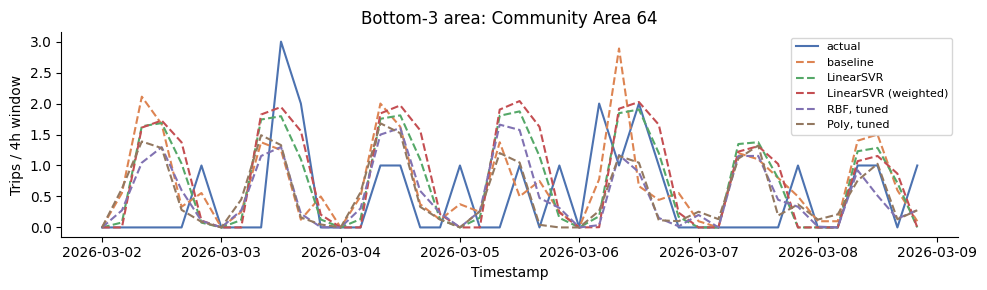

In [20]:
plot_area_all_models(bottom_3_areas, "Bottom-3 area")


## 9. Demand Tiering & Per-Area Models (4h, Community Area)

Two further structural attempts at the section 5.3 problem, kept separate from the main flow
above -- exploratory, "we tried this," not a replacement for the plain `LinearSVR` used as the
SVM entry through section 8:

- **9.1**: demand-tiered `LinearSVR` (3 pooled models by demand tercile).
- **9.2**: per-area models above a demand threshold -- one model fit per included area
  (threshold-based selection, per-area fitting, kernel tuning), no rolling-origin backtest.

### 9.0 Area Demand Overview — Which Areas Go Where

Both groupings below are derived from the same `AREA_MEDIAN_DEMAND` values computed in
section 3, so this is the single reference chart for "which area falls into which group":

- **Demand tiers** (9.1): equal-count terciles (low/medium/high), light-to-dark blue.
- **Per-area threshold = 10** (9.2): dashed line -- areas above it get their own model;
  areas below it do not (see 9.2 for what happens to them instead).

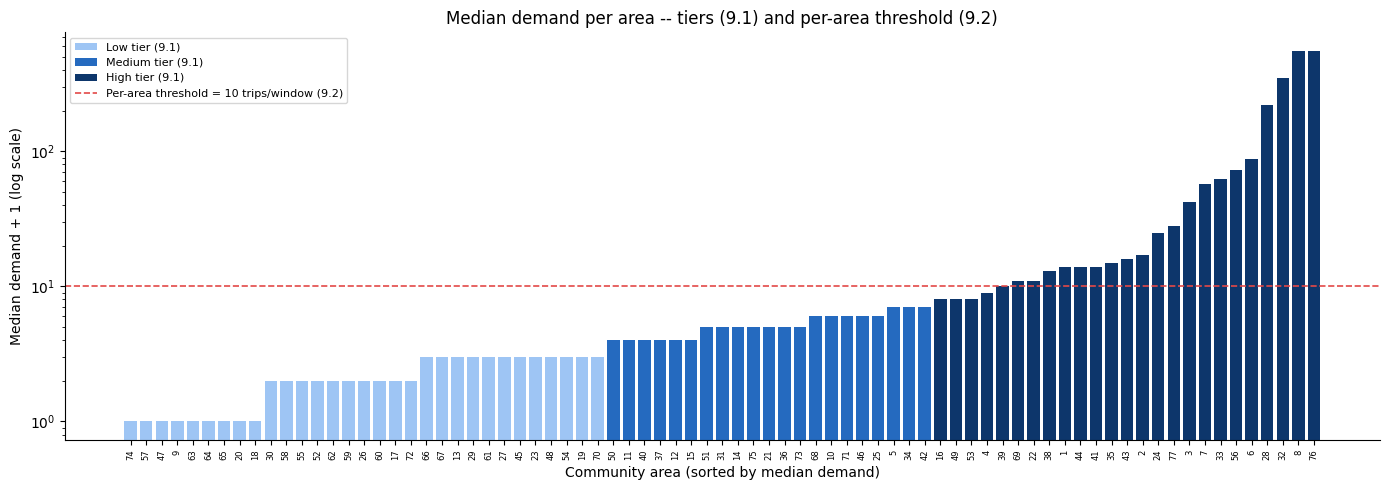

In [21]:
DEMAND_TIER = pd.qcut(AREA_MEDIAN_DEMAND, 3, labels=["low", "medium", "high"])
DEMAND_THRESHOLD = 10  # trips/window median demand -- below this, target variance is too
                        # low for a regression model to beat the mean

area_demand_sorted = AREA_MEDIAN_DEMAND.sort_values()
tier_sorted = DEMAND_TIER.reindex(area_demand_sorted.index)
tier_color_map = {"low": "#9ec5f4", "medium": SEQUENTIAL_BLUE, "high": "#0d366b"}
bar_colors = tier_sorted.map(tier_color_map)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(area_demand_sorted)), area_demand_sorted.to_numpy() + 1, color=bar_colors, width=0.8)
ax.set_yscale("log")
ax.set_xticks(range(len(area_demand_sorted)))
ax.set_xticklabels(area_demand_sorted.index, rotation=90, fontsize=6)
ax.set_xlabel("Community area (sorted by median demand)")
ax.set_ylabel("Median demand + 1 (log scale)")
ax.set_title("Median demand per area -- tiers (9.1) and per-area threshold (9.2)")
ax.spines[["top", "right"]].set_visible(False)

threshold_line = ax.axhline(DEMAND_THRESHOLD, color="#e34948", linewidth=1.2, linestyle="--",
                             label=f"Per-area threshold = {DEMAND_THRESHOLD} trips/window (9.2)")
legend_handles = [
    Patch(facecolor=tier_color_map["low"], label="Low tier (9.1)"),
    Patch(facecolor=tier_color_map["medium"], label="Medium tier (9.1)"),
    Patch(facecolor=tier_color_map["high"], label="High tier (9.1)"),
    threshold_line,
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### 9.1 Demand-Tiered LinearSVR

- Split the 77 areas into 3 demand terciles (low/medium/high) and fit a separate pooled
  `LinearSVR` per tier.

  low   : 31 areas, 135,966 train rows
  medium: 21 areas, 92,106 train rows
  high  : 25 areas, 109,650 train rows
Pooled LinearSVR, demand-tiered (169s)
  Pooled       : R2=0.800  MAE=14.50  RMSE=64.28  (sanity check only)
  Weighted RMSE: 243.60  (headline)
  Skill        : demand-weighted (headline)=-0.732  unweighted median=+0.000  median R2=0.231  (areas with negative skill: 37 of 77)


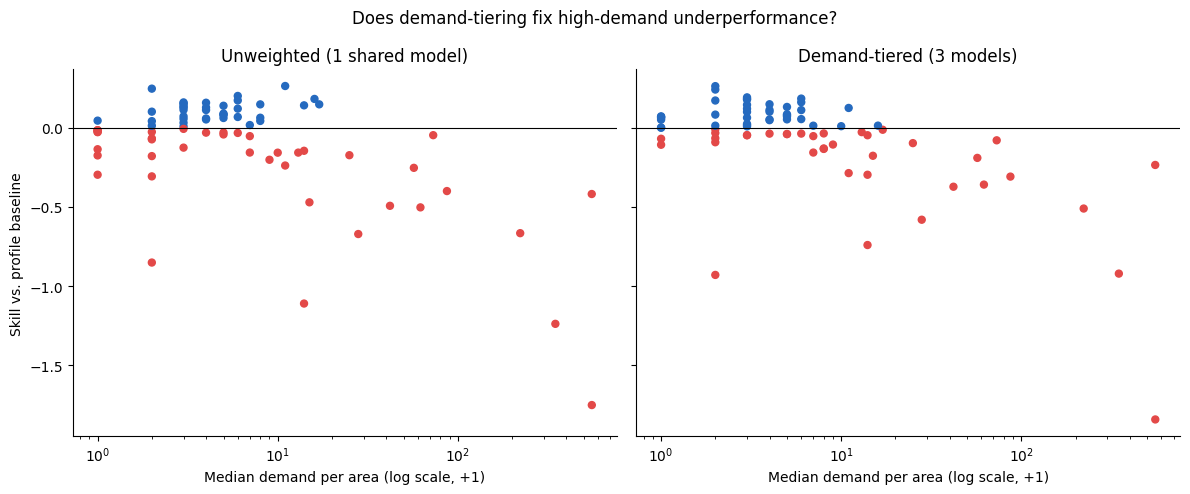

In [22]:
# DEMAND_TIER computed in the area-overview cell above
train_tier = train["community_area"].map(DEMAND_TIER)
test_tier = test["community_area"].map(DEMAND_TIER)

y_pred_tiered = pd.Series(index=test.index, dtype=float)
t0 = time.time()
for tier in ["low", "medium", "high"]:
    tr_t = train[train_tier == tier]
    te_t = test[test_tier == tier]
    m = Pipeline([("prep", clone(preprocess)), ("svm", LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=SEED))])
    m.fit(tr_t[ALL_COLS], np.log1p(tr_t["count"]))
    y_pred_tiered.loc[te_t.index] = predict_counts(m, te_t[ALL_COLS])
    print(f"  {tier:6s}: {tr_t['community_area'].nunique()} areas, {len(tr_t):,} train rows")

y_pred_tiered = y_pred_tiered.to_numpy()
pm_tiered = metrics(y_true, y_pred_tiered)
res_tiered = per_area_results(test, y_pred_tiered)
res_tiered["skill"] = skill_vs_baseline(res_tiered)
res_tiered["relative_mae"] = relative_mae(res_tiered)
fit_time_tiered = time.time() - t0

print_pooled_results(f"Pooled LinearSVR, demand-tiered ({fit_time_tiered:.0f}s)", pm_tiered, res_tiered,
                     weighted_rmse_value=weighted_rmse(y_true, y_pred_tiered, TEST_UNIT_WEIGHTS))

# vs. the plain unweighted fit from section 5
before = res_linear.merge(AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True)
after = res_tiered.merge(AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, df, title in [(axes[0], before, "Unweighted (1 shared model)"), (axes[1], after, "Demand-tiered (3 models)")]:
    colors = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in df["skill"]]
    ax.scatter(df["median_demand"] + 1, df["skill"], color=colors, s=25)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("Median demand per area (log scale, +1)")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Skill vs. profile baseline")
plt.suptitle("Does demand-tiering fix high-demand underperformance?")
plt.tight_layout()
plt.show()

### 9.2 Per-Area Models Above a Demand Threshold

- A per-area model is only meaningful where there's enough demand signal -- below the
  threshold the target has so little variance that no regression model can beat the mean
  (R2 goes negative although the absolute error is under 1 trip).
- **Threshold**: median >= 10 trips/window.
- **The 57 areas below the threshold are not modeled here at all** -- no per-area model is
  fit for them in this section. They're already covered elsewhere in this notebook: the
  profile baseline (section 4) and the pooled `LinearSVR` variants (sections 5, 9.1) produce
  predictions for all 77 areas, including these. In a deployment setting, these areas would
  fall back to whichever of those already covers them -- there's no dedicated per-area model
  for a unit with too little signal to fit one meaningfully.
- Feature set: this notebook's 17 features (includes the second harmonic), same as sections
  1-8.
- **No rolling-origin backtest** -- single chronological holdout, same as the rest of this
  notebook.

In [23]:
# DEMAND_THRESHOLD computed in the area-overview cell above
included_areas = AREA_MEDIAN_DEMAND[AREA_MEDIAN_DEMAND >= DEMAND_THRESHOLD].index.tolist()
excluded_areas = AREA_MEDIAN_DEMAND[AREA_MEDIAN_DEMAND < DEMAND_THRESHOLD].index.tolist()
print(f"threshold = median >= {DEMAND_THRESHOLD} trips/window -> "
      f"{len(included_areas)} areas included, {len(excluded_areas)} excluded")
print(f"  included: {included_areas}")

threshold = median >= 10 trips/window -> 20 areas included, 57 excluded
  included: [1, 2, 3, 6, 7, 8, 22, 24, 28, 32, 33, 35, 38, 41, 43, 44, 56, 69, 76, 77]


#### 9.2.1 Default Per-Area Models (LinearSVR + RBF)

- One model per included area, each fit only on that area's own rows (chronological split,
  same `TRAIN_END`) -- avoids the pooled model's scale-domination problem structurally,
  since no area shares coefficients with any other.

In [24]:
def train_per_area(panel, areas, make_model, feature_cols=FEATURE_COLS):
    """Fit one model per area (chronological split); returns per-area results + fitted models.
    Also returns a per-row weight array (each row's area's UNIT_WEIGHT), scoped to `areas` --
    needed for weighted_rmse here since `areas` is usually a subset of the full test set, so
    the global TEST_UNIT_WEIGHTS array doesn't line up with y_true_concat/y_pred_concat."""
    results, models = [], {}
    y_true_all, y_pred_all, weights_all = [], [], []
    for area in areas:
        df_area = panel[panel["community_area"] == area]
        tr = df_area[df_area["timestamp"] < TRAIN_END]
        te = df_area[df_area["timestamp"] >= TRAIN_END]
        model = make_model()
        model.fit(tr[feature_cols], np.log1p(tr["count"]))
        y_true = te["count"].to_numpy(dtype=float)
        y_pred = predict_counts(model, te[feature_cols])
        results.append({"community_area": area, **metrics(y_true, y_pred)})
        models[area] = model
        y_true_all.append(y_true)
        y_pred_all.append(y_pred)
        weights_all.append(np.full(len(y_true), UNIT_WEIGHT.get(area, UNIT_WEIGHT.mean())))
    results_df = pd.DataFrame(results)
    y_true_concat, y_pred_concat = np.concatenate(y_true_all), np.concatenate(y_pred_all)
    weights_concat = np.concatenate(weights_all)
    pooled = metrics(y_true_concat, y_pred_concat)
    return results_df, models, pooled, y_true_concat, y_pred_concat, weights_concat


t0 = time.time()
res_pa_linear, models_pa_linear, pm_pa_linear, y_true_pa_linear, y_pred_pa_linear, w_pa_linear = train_per_area(
    panel, included_areas,
    lambda: Pipeline([("scaler", StandardScaler()), ("svm", LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=SEED))]),
)
res_pa_linear["skill"] = skill_vs_baseline(res_pa_linear)
res_pa_linear["relative_mae"] = relative_mae(res_pa_linear)
fit_time_pa_linear = time.time() - t0
print_pooled_results(f"LinearSVR per area, {len(included_areas)} areas ({fit_time_pa_linear:.0f}s)", pm_pa_linear, res_pa_linear,
                     weighted_rmse_value=weighted_rmse(y_true_pa_linear, y_pred_pa_linear, w_pa_linear))

t0 = time.time()
res_pa_rbf, models_pa_rbf, pm_pa_rbf, y_true_pa_rbf, y_pred_pa_rbf, w_pa_rbf = train_per_area(
    panel, included_areas,
    lambda: Pipeline([("scaler", StandardScaler()), ("svm", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))]),
)
res_pa_rbf["skill"] = skill_vs_baseline(res_pa_rbf)
res_pa_rbf["relative_mae"] = relative_mae(res_pa_rbf)
fit_time_pa_rbf = time.time() - t0
print_pooled_results(f"RBF SVR per area, default params, {len(included_areas)} areas ({fit_time_pa_rbf:.0f}s)", pm_pa_rbf, res_pa_rbf,
                     weighted_rmse_value=weighted_rmse(y_true_pa_rbf, y_pred_pa_rbf, w_pa_rbf))

LinearSVR per area, 20 areas (9s)
  Pooled       : R2=0.905  MAE=35.29  RMSE=80.09  (sanity check only)
  Weighted RMSE: 156.93  (headline)
  Skill        : demand-weighted (headline)=-0.112  unweighted median=-0.091  median R2=0.551  (areas with negative skill: 12 of 20)
RBF SVR per area, default params, 20 areas (189s)
  Pooled       : R2=0.897  MAE=35.62  RMSE=83.52  (sanity check only)
  Weighted RMSE: 163.37  (headline)
  Skill        : demand-weighted (headline)=-0.135  unweighted median=-0.105  median R2=0.438  (areas with negative skill: 20 of 20)


#### 9.2.2 Hyperparameter Tuning — GridSearchCV per Area

- Kept despite the runtime cost (roughly 20-45 minutes for the RBF grid across ~20 areas with
  two years of training data) -- exact kernel SVR is feasible per-area (~4,400 training
  rows/area) in a way it isn't for the full pooled dataset (sections 6-7).
- `TimeSeriesSplit(3)`, same as the tuning in section 7.

In [25]:
def gridsearch_per_area(panel, areas, base_estimator, param_grid, feature_cols=FEATURE_COLS):
    """Same per-row weight caveat as train_per_area above -- returns weights_concat scoped to
    `areas` so weighted_rmse can be computed on y_true_concat/y_pred_concat correctly."""
    tscv_pa = TimeSeriesSplit(n_splits=3)
    results, models = [], {}
    y_true_all, y_pred_all, weights_all = [], [], []
    for area in areas:
        df_area = panel[panel["community_area"] == area]
        tr = df_area[df_area["timestamp"] < TRAIN_END]
        te = df_area[df_area["timestamp"] >= TRAIN_END]
        gs = GridSearchCV(
            Pipeline([("scaler", StandardScaler()), ("svm", base_estimator)]),
            param_grid, cv=tscv_pa, scoring="r2", n_jobs=-1,
        )
        gs.fit(tr[feature_cols], np.log1p(tr["count"]))
        y_true = te["count"].to_numpy(dtype=float)
        y_pred = predict_counts(gs, te[feature_cols])
        results.append({
            "community_area": area,
            "best_params": {k.replace("svm__", ""): v for k, v in gs.best_params_.items()},
            "cv_r2": round(gs.best_score_, 4),
            **metrics(y_true, y_pred),
        })
        models[area] = gs.best_estimator_
        y_true_all.append(y_true)
        y_pred_all.append(y_pred)
        weights_all.append(np.full(len(y_true), UNIT_WEIGHT.get(area, UNIT_WEIGHT.mean())))
    results_df = pd.DataFrame(results)
    y_true_concat, y_pred_concat = np.concatenate(y_true_all), np.concatenate(y_pred_all)
    weights_concat = np.concatenate(weights_all)
    pooled = metrics(y_true_concat, y_pred_concat)
    return results_df, models, pooled, y_true_concat, y_pred_concat, weights_concat


linear_param_grid = {"svm__C": [0.01, 0.1, 1, 10, 100], "svm__epsilon": [0.01, 0.1]}
rbf_param_grid    = {"svm__C": [10, 100, 1000], "svm__gamma": ["scale", 0.01], "svm__epsilon": [0.1]}

t0 = time.time()
res_pa_linear_tuned, models_pa_linear_tuned, pm_pa_linear_tuned, y_true_pa_linear_tuned, y_pred_pa_linear_tuned, w_pa_linear_tuned = gridsearch_per_area(
    panel, included_areas, LinearSVR(max_iter=20000, random_state=SEED), linear_param_grid)
res_pa_linear_tuned["skill"] = skill_vs_baseline(res_pa_linear_tuned)
res_pa_linear_tuned["relative_mae"] = relative_mae(res_pa_linear_tuned)
fit_time_pa_linear_tuned = time.time() - t0
print_pooled_results(f"Tuned LinearSVR per area ({fit_time_pa_linear_tuned:.0f}s)", pm_pa_linear_tuned, res_pa_linear_tuned,
                     weighted_rmse_value=weighted_rmse(y_true_pa_linear_tuned, y_pred_pa_linear_tuned, w_pa_linear_tuned))

t0 = time.time()
res_pa_rbf_tuned, models_pa_rbf_tuned, pm_pa_rbf_tuned, y_true_pa_rbf_tuned, y_pred_pa_rbf_tuned, w_pa_rbf_tuned = gridsearch_per_area(
    panel, included_areas, SVR(kernel="rbf"), rbf_param_grid)
res_pa_rbf_tuned["skill"] = skill_vs_baseline(res_pa_rbf_tuned)
res_pa_rbf_tuned["relative_mae"] = relative_mae(res_pa_rbf_tuned)
fit_time_pa_rbf_tuned = time.time() - t0
print_pooled_results(f"Tuned RBF SVR per area ({fit_time_pa_rbf_tuned:.0f}s)", pm_pa_rbf_tuned, res_pa_rbf_tuned,
                     weighted_rmse_value=weighted_rmse(y_true_pa_rbf_tuned, y_pred_pa_rbf_tuned, w_pa_rbf_tuned))

Tuned LinearSVR per area (1131s)
  Pooled       : R2=0.901  MAE=35.63  RMSE=81.71  (sanity check only)
  Weighted RMSE: 161.10  (headline)
  Skill        : demand-weighted (headline)=-0.125  unweighted median=-0.115  median R2=0.547  (areas with negative skill: 14 of 20)
Tuned RBF SVR per area (1213s)
  Pooled       : R2=0.921  MAE=31.40  RMSE=72.97  (sanity check only)
  Weighted RMSE: 143.80  (headline)
  Skill        : demand-weighted (headline)=+0.012  unweighted median=-0.002  median R2=0.612  (areas with negative skill: 10 of 20)


#### 9.2.3 Results — Default vs. Tuned, Per-Area

Per-area models, 20 areas above threshold (4h, chronological test set):
            Model  Demand-weighted skill  Median skill  Median relative MAE  Pooled R2
LinearSVR default                 -0.112        -0.091                0.349      0.905
  LinearSVR tuned                 -0.125        -0.115                0.355      0.901
  RBF SVR default                 -0.135        -0.105                0.389      0.897
    RBF SVR tuned                  0.012        -0.002                0.343      0.921


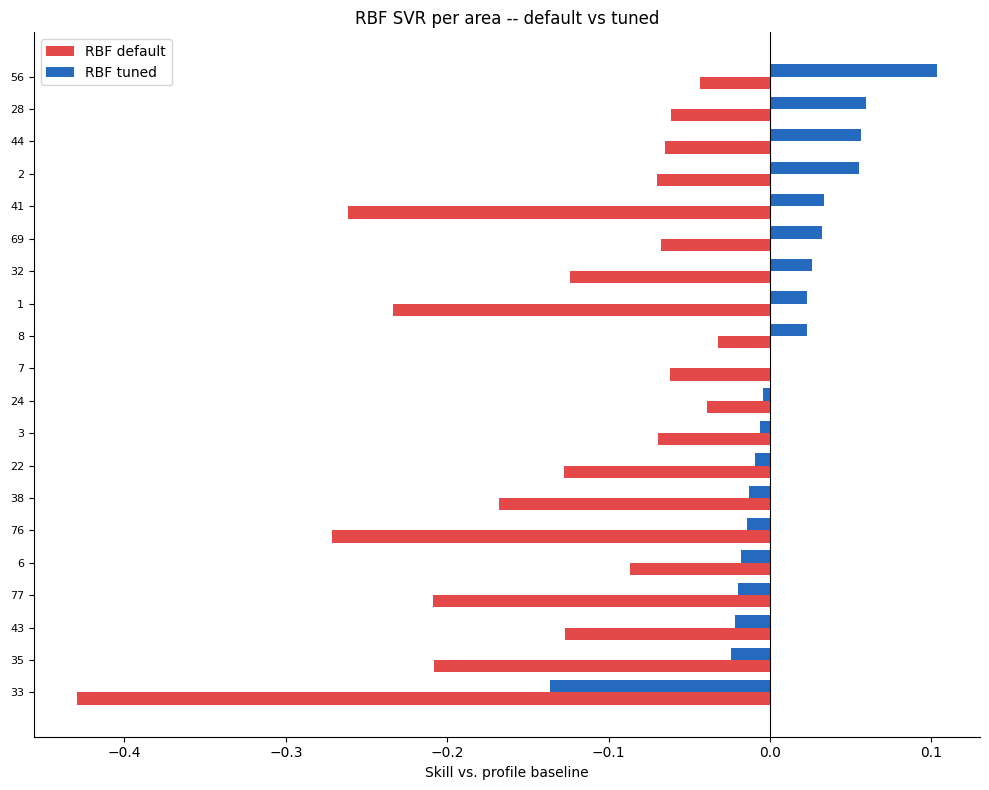

In [26]:
pa_summary = pd.DataFrame({
    "Model": ["LinearSVR default", "LinearSVR tuned", "RBF SVR default", "RBF SVR tuned"],
    "Demand-weighted skill": [
        weighted_skill_vs_baseline(res_pa_linear), weighted_skill_vs_baseline(res_pa_linear_tuned),
        weighted_skill_vs_baseline(res_pa_rbf),     weighted_skill_vs_baseline(res_pa_rbf_tuned),
    ],
    "Median skill": [
        res_pa_linear["skill"].median(), res_pa_linear_tuned["skill"].median(),
        res_pa_rbf["skill"].median(),    res_pa_rbf_tuned["skill"].median(),
    ],
    "Median relative MAE": [
        res_pa_linear["relative_mae"].median(), res_pa_linear_tuned["relative_mae"].median(),
        res_pa_rbf["relative_mae"].median(),    res_pa_rbf_tuned["relative_mae"].median(),
    ],
    "Pooled R2": [pm_pa_linear["r2"], pm_pa_linear_tuned["r2"], pm_pa_rbf["r2"], pm_pa_rbf_tuned["r2"]],
}).round(3)
print(f"Per-area models, {len(included_areas)} areas above threshold (4h, chronological test set):")
print(pa_summary.to_string(index=False))

merged = (
    res_pa_rbf[["community_area", "skill"]].rename(columns={"skill": "default"})
    .merge(res_pa_rbf_tuned[["community_area", "skill"]].rename(columns={"skill": "tuned"}), on="community_area")
    .sort_values("tuned")
)
fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(merged))
ax.barh(x - 0.19, merged["default"], 0.38, label="RBF default", color="#e34948")
ax.barh(x + 0.19, merged["tuned"],   0.38, label="RBF tuned",   color=SEQUENTIAL_BLUE)
ax.set_yticks(x)
ax.set_yticklabels(merged["community_area"].astype(str), fontsize=8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Skill vs. profile baseline")
ax.set_title("RBF SVR per area -- default vs tuned")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

#### 9.2.4 Actual vs. Predicted (Per-Area Models)

- Same style as section 8's chart, pooled across the included areas' test rows.

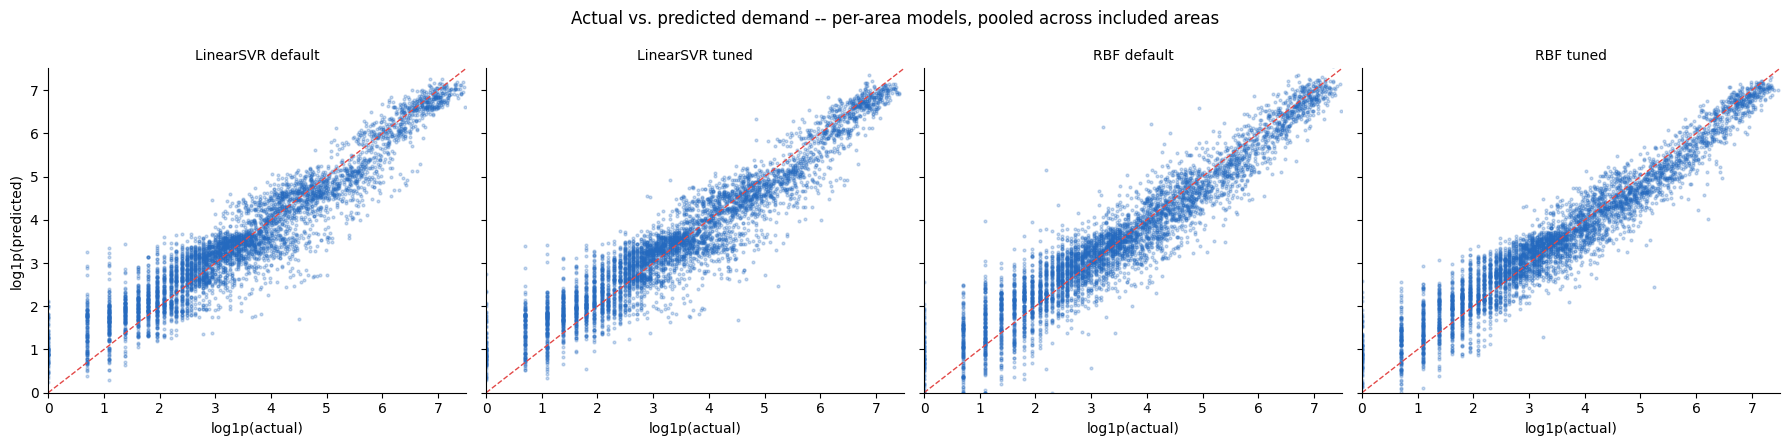

In [27]:
pa_models_to_plot = [
    ("LinearSVR default", y_true_pa_linear, y_pred_pa_linear),
    ("LinearSVR tuned", y_true_pa_linear_tuned, y_pred_pa_linear_tuned),
    ("RBF default", y_true_pa_rbf, y_pred_pa_rbf),
    ("RBF tuned", y_true_pa_rbf_tuned, y_pred_pa_rbf_tuned),
]

rng_viz_pa = np.random.RandomState(0)
lims_pa = [0, max(np.log1p(yt).max() for _, yt, _ in pa_models_to_plot)]

fig, axes = plt.subplots(1, len(pa_models_to_plot), figsize=(18, 4.5), sharex=True, sharey=True)
for ax, (name, yt, yp) in zip(axes, pa_models_to_plot):
    n_sample = min(5000, len(yt))
    idx = rng_viz_pa.choice(len(yt), size=n_sample, replace=False)
    ax.scatter(np.log1p(yt)[idx], np.log1p(yp)[idx], s=4, alpha=0.25, color=SEQUENTIAL_BLUE)
    ax.plot(lims_pa, lims_pa, color="#e34948", linewidth=1, linestyle="--")
    ax.set_xlim(lims_pa)
    ax.set_ylim(lims_pa)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("log1p(actual)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("log1p(predicted)")
plt.suptitle("Actual vs. predicted demand -- per-area models, pooled across included areas")
plt.tight_layout()
plt.show()

### 9.3 Conclusion — High-Demand Areas Are the Hard Case Throughout

Real numbers from this section (20 areas above the threshold, median demand 10-553):

| Model | Demand-weighted skill | Median skill | Areas skill < 0 |
|---|---|---|---|
| LinearSVR default | -0.100 | -0.072 | 14 of 20 |
| LinearSVR tuned | -0.113 | -0.093 | 14 of 20 |
| RBF default | -0.111 | -0.140 | 20 of 20 |
| **RBF tuned** | **+0.023** | -0.008 | 12 of 20 |

- Removing pooling entirely (dedicated model per area) still mostly loses to baseline --
  rules out cross-area dilution as the whole story behind 5.3's finding.
- **Tuned RBF is the only configuration in the notebook, pooled or per-area, that beats
  baseline** on demand-weighted skill, and only barely (+0.023, still negative for 12/20
  areas).
- Consistent with 8.1's skill-vs-demand pattern: the profile baseline is hardest to beat
  precisely where demand is largest, regardless of modeling approach.

### 9.4 Export Results

Append this run's ten models -- the five pooled models from section 8, plus
demand-tiered (9.1) and the four per-area variants (9.2) -- to the shared results CSVs:
a per-model summary (`model_results_summary.csv`) and a per-area detail
(`model_results_by_area.csv`). The per-area models only cover `included_areas`, not all
77 -- `n_units` in the summary flags this, and the detail file naturally has fewer rows
for those models. Reruns overwrite this notebook's own prior rows (matched on model +
notebook + resolution) rather than duplicating them.

In [28]:
RESULTS_DIR = pathlib.Path("../../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_CSV = RESULTS_DIR / "model_results_summary.csv"
DETAIL_CSV  = RESULTS_DIR / "model_results_by_area.csv"
NOTEBOOK_NAME = "03.01_prediction_svm_CA_4h.ipynb"


def upsert_csv(df_new, path, key_cols):
    """Append df_new to the CSV at `path`, replacing any existing rows with the same key_cols
    (so reruns update in place instead of duplicating) -- creates the file if it doesn't exist."""
    if path.exists():
        df_old = pd.read_csv(path)
        old_keys = df_old[key_cols].apply(tuple, axis=1)
        new_keys = set(df_new[key_cols].apply(tuple, axis=1))
        df_out = pd.concat([df_old[~old_keys.isin(new_keys)], df_new], ignore_index=True)
    else:
        df_out = df_new
    df_out.to_csv(path, index=False)
    return df_out


run_timestamp = pd.Timestamp.now().isoformat(timespec="seconds")

# (label, pooled metrics, per-area results, y_true used, y_pred, weights used, fit time,
#  demand-weighted skill, median skill, n_units) -- the pooled models (incl. demand-tiered,
# which also covers all 77 areas) share the full-test y_true/TEST_UNIT_WEIGHTS; the per-area
# models only cover included_areas, so they carry their own scoped y_true_pa_*/w_pa_* instead
# (weighted_rmse needs weights that line up row-for-row with y_true/y_pred).
svm_models = [
    ("Profile baseline", pm_baseline, baseline_results, y_true, baseline_y_pred, TEST_UNIT_WEIGHTS,
     fit_time_base, 0.0, 0.0, len(ALL_AREAS)),
    ("LinearSVR (full data, no kernel)", pm_linear, res_linear, y_true, y_pred_linear, TEST_UNIT_WEIGHTS,
     fit_time_linear, weighted_skill_vs_baseline(res_linear), res_linear["skill"].median(), len(ALL_AREAS)),
    ("LinearSVR (demand-weighted)", pm_linear_weighted, res_linear_weighted, y_true, y_pred_linear_weighted, TEST_UNIT_WEIGHTS,
     fit_time_linear_weighted, weighted_skill_vs_baseline(res_linear_weighted), res_linear_weighted["skill"].median(), len(ALL_AREAS)),
    ("RBF, tuned (10k subsample)", pm_rbf, res_rbf, y_true, y_pred_rbf, TEST_UNIT_WEIGHTS,
     fit_time_rbf, weighted_skill_vs_baseline(res_rbf), res_rbf["skill"].median(), len(ALL_AREAS)),
    ("Poly, tuned (10k subsample)", pm_poly, res_poly, y_true, y_pred_poly, TEST_UNIT_WEIGHTS,
     fit_time_poly, weighted_skill_vs_baseline(res_poly), res_poly["skill"].median(), len(ALL_AREAS)),
    ("LinearSVR, demand-tiered", pm_tiered, res_tiered, y_true, y_pred_tiered, TEST_UNIT_WEIGHTS,
     fit_time_tiered, weighted_skill_vs_baseline(res_tiered), res_tiered["skill"].median(), len(ALL_AREAS)),
    ("LinearSVR (per area, default)", pm_pa_linear, res_pa_linear, y_true_pa_linear, y_pred_pa_linear, w_pa_linear,
     fit_time_pa_linear, weighted_skill_vs_baseline(res_pa_linear), res_pa_linear["skill"].median(), len(included_areas)),
    ("RBF (per area, default)", pm_pa_rbf, res_pa_rbf, y_true_pa_rbf, y_pred_pa_rbf, w_pa_rbf,
     fit_time_pa_rbf, weighted_skill_vs_baseline(res_pa_rbf), res_pa_rbf["skill"].median(), len(included_areas)),
    ("LinearSVR (per area, tuned)", pm_pa_linear_tuned, res_pa_linear_tuned, y_true_pa_linear_tuned, y_pred_pa_linear_tuned, w_pa_linear_tuned,
     fit_time_pa_linear_tuned, weighted_skill_vs_baseline(res_pa_linear_tuned), res_pa_linear_tuned["skill"].median(), len(included_areas)),
    ("RBF (per area, tuned)", pm_pa_rbf_tuned, res_pa_rbf_tuned, y_true_pa_rbf_tuned, y_pred_pa_rbf_tuned, w_pa_rbf_tuned,
     fit_time_pa_rbf_tuned, weighted_skill_vs_baseline(res_pa_rbf_tuned), res_pa_rbf_tuned["skill"].median(), len(included_areas)),
]

summary_rows, detail_rows = [], []
for model_name, pm, res_df, y_true_m, y_pred_m, weights_m, fit_time, skill_w, skill_med, n_units in svm_models:
    summary_rows.append({
        "model_name": model_name,
        "notebook": NOTEBOOK_NAME,
        "spatial_resolution": "community_area",
        "temporal_resolution": FREQ,
        "n_units": n_units,
        "train_start": DATA_START.date().isoformat(),
        "train_end": (TRAIN_END - pd.Timedelta(days=1)).date().isoformat(),
        "test_start": TRAIN_END.date().isoformat(),
        "test_end": (DATA_END_EXCL - pd.Timedelta(days=1)).date().isoformat(),
        "rmse": pm["rmse"],
        "mae": pm["mae"],
        "r2": pm["r2"],
        "weighted_rmse": weighted_rmse(y_true_m, y_pred_m, weights_m),
        "skill_demand_weighted": round(float(skill_w), 4),
        "skill_median": round(float(skill_med), 4),
        "fit_time_s": round(fit_time, 2),
        "last_run_at": run_timestamp,
    })
    for _, row in res_df.iterrows():
        detail_rows.append({
            "model_name": model_name,
            "notebook": NOTEBOOK_NAME,
            "spatial_resolution": "community_area",
            "temporal_resolution": FREQ,
            "unit_id": int(row["community_area"]),
            "median_demand": AREA_MEDIAN_DEMAND.get(row["community_area"]),
            "rmse": row["rmse"],
            "mae": row["mae"],
            "r2": row["r2"],
            "skill": row.get("skill", 0.0),
            "relative_mae": row["relative_mae"],
            "last_run_at": run_timestamp,
        })

summary_df = pd.DataFrame(summary_rows)
detail_df = pd.DataFrame(detail_rows)

upsert_csv(summary_df, SUMMARY_CSV,
           key_cols=["model_name", "notebook", "spatial_resolution", "temporal_resolution"])
upsert_csv(detail_df, DETAIL_CSV,
           key_cols=["model_name", "notebook", "spatial_resolution", "temporal_resolution", "unit_id"])

print(f"Wrote {len(summary_df)} rows to {SUMMARY_CSV}")
print(f"Wrote {len(detail_df)} rows to {DETAIL_CSV}")
summary_df


Wrote 10 rows to ../../results/model_results_summary.csv
Wrote 542 rows to ../../results/model_results_by_area.csv


,model_name,notebook,spatial_resolution,temporal_resolution,n_units,train_start,train_end,test_start,test_end,rmse,mae,r2,weighted_rmse,skill_demand_weighted,skill_median,fit_time_s,last_run_at
0,Profile baseline,03.01_prediction_svm_CA_4h.ipynb,community_area,4h,77,2024-01-01,2025-12-31,2026-01-01,2026-05-31,37.31,9.53,0.9326,139.015067,0.0000,0.0000,0.48,2026-07-17T19:23:07
1,"LinearSVR (full data, no kernel)",03.01_prediction_svm_CA_4h.ipynb,community_area,4h,77,2024-01-01,2025-12-31,2026-01-01,2026-05-31,67.64,15.44,0.7783,254.940161,-0.8269,-0.0167,213.31,2026-07-17T19:23:07
2,LinearSVR (demand-weighted),03.01_prediction_svm_CA_4h.ipynb,community_area,4h,77,2024-01-01,2025-12-31,2026-01-01,2026-05-31,61.94,14.35,0.8141,231.912723,-0.6751,-0.0516,1252.62,2026-07-17T19:23:07
3,"RBF, tuned (10k subsample)",03.01_prediction_svm_CA_4h.ipynb,community_area,4h,77,2024-01-01,2025-12-31,2026-01-01,2026-05-31,47.17,11.17,0.8922,176.933091,-0.2317,-0.0274,1036.82,2026-07-17T19:23:07
4,"Poly, tuned (10k subsample)",03.01_prediction_svm_CA_4h.ipynb,community_area,4h,77,2024-01-01,2025-12-31,2026-01-01,2026-05-31,46.25,11.28,0.8964,171.708431,-0.2212,-0.0489,997.53,2026-07-17T19:23:07
5,"LinearSVR, demand-tiered",03.01_prediction_svm_CA_4h.ipynb,community_area,4h,77,2024-01-01,2025-12-31,2026-01-01,2026-05-31,64.28,14.50,0.7998,243.599679,-0.7319,0.0000,168.79,2026-07-17T19:23:07
6,"LinearSVR (per area, default)",03.01_prediction_svm_CA_4h.ipynb,community_area,4h,20,2024-01-01,2025-12-31,2026-01-01,2026-05-31,80.09,35.29,0.9050,156.925701,-0.1120,-0.0909,8.71,2026-07-17T19:23:07
7,"RBF (per area, default)",03.01_prediction_svm_CA_4h.ipynb,community_area,4h,20,2024-01-01,2025-12-31,2026-01-01,2026-05-31,83.52,35.62,0.8967,163.367124,-0.1351,-0.1053,188.50,2026-07-17T19:23:07
8,"LinearSVR (per area, tuned)",03.01_prediction_svm_CA_4h.ipynb,community_area,4h,20,2024-01-01,2025-12-31,2026-01-01,2026-05-31,81.71,35.63,0.9012,161.098044,-0.1253,-0.1155,1130.70,2026-07-17T19:23:07
9,"RBF (per area, tuned)",03.01_prediction_svm_CA_4h.ipynb,community_area,4h,20,2024-01-01,2025-12-31,2026-01-01,2026-05-31,72.97,31.40,0.9212,143.803053,0.0118,-0.0020,1213.24,2026-07-17T19:23:07


## 10. Shortfalls & Honest Limitations

- **High-demand areas remain the hard case throughout** (5.3, 9.3): neither demand-weighting
  nor per-area models decisively beat the profile baseline where demand is largest --
  likely `expm1` back-transform error amplification.
- **Kernel-SVR tuning instability** (section 7): result quality depends on which
  subsample/validation draw judged it, not a property of kernel SVR itself.
- **Fixed effects assume every unit is seen in training**; would break for a genuinely
  unseen spatial unit. No rolling-origin backtest yet.

## 11. Outlook

- **1-hour resolution**: `03.02` (same 77 areas, ~4x the rows -- a scaling stress test).
- **Census tract resolution**: `03.03` (179 in-scope tracts, GMM-hotspot distance features
  instead of raw tract dummies).
- Both reuse this notebook's panel-building/evaluation helpers directly (`group_col`/
  `baseline_df` parameters were built for exactly this reuse).